# ACTUWISE — Module 1 : Analyse de la Sinistralité Automobile

---

**Projet** : ACTUWISE — Plateforme d'Analyse Actuarielle, de Modélisation des Risques et d'Aide à la Décision en Assurance Non-Vie  
**Module** : Module 1 — Analyse de la sinistralité automobile  
**Source de données** : `SAP_AUTO_PAR_GARANTIES_AU_31122023_-_MAJ.xls`  
**Jointure (ratio combiné)** : `Base_production_sur_6_ans.xlsx`

---

## Objectifs du module

Ce module constitue le **point d'entrée analytique** du projet ACTUWISE. Avant toute modélisation ou provisionnement, une compréhension approfondie des données brutes est indispensable. Les résultats obtenus ici servent de fondation documentée aux hypothèses retenues dans tous les modules suivants.

| Objectif | Description |
|----------|-------------|
| **Obj 1** | Analyse descriptive de la sinistralité (fréquence, coût, temporalité) |
| **Obj 2** | Analyse des délais de déclaration et quantification de l'IBNR |
| **Obj 3** | Calcul du ratio combiné et analyse de la rentabilité |
| **Obj 4** | Indicateurs actuariels clés (charge ultime, taux de développement) |
| **Obj 5** | Visualisations professionnelles exportables vers Power BI |

---

## 0. Imports & Configuration

In [32]:
# ── Imports standard ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Palette ACTUWISE ──────────────────────────────────────────────────────────
PALETTE = {
    'bleu_fonce': '#1a3c6e',
    'vert_actuaire': '#1a7a6a',
    'rouge_alerte': '#c0392b',
    'orange': '#e67e22',
    'violet': '#8e44ad',
    'gris': '#7f8c8d',
    'bleu_clair': '#2980b9',
    'vert_clair': '#27ae60'
}
COLOR_LIST = list(PALETTE.values())

# ── Style global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
sns.set_palette(COLOR_LIST)

# ── Chemins fichiers ──────────────────────────────────────────────────────────
PATH_SINISTRES  = 'SAP_AUTO_PAR_GARANTIES_AU_31122023_-_MAJ.xls'
PATH_PRODUCTION = 'Base_production_sur_6_ans.xlsx'

# ── Seuils actuariels ─────────────────────────────────────────────────────────
SEUIL_SINISTRE_GRAVE   = 50_000   # DT
SEUIL_DECLARATION_TARD = 30       # jours
SEUIL_RATIO_SINISTRES  = 0.70
SEUIL_RATIO_COMBINE    = 1.00

print("✅ Imports et configuration OK")
print(f"   Palette : {list(PALETTE.keys())}")

✅ Imports et configuration OK
   Palette : ['bleu_fonce', 'vert_actuaire', 'rouge_alerte', 'orange', 'violet', 'gris', 'bleu_clair', 'vert_clair']


---
## 1. Chargement et rappel des données

Le fichier `SAP_AUTO_PAR_GARANTIES_AU_31122023_-_MAJ.xls` contient **64 999 dossiers sinistres** sur la période 2004–2023. Chaque ligne représente un sinistre individuel avec :
- La **date de survenance** (`TMP_CLMLOSS_DATE`) et la **date de déclaration** (`CLM_REPORTED_DATE`)
- Le **type** (M = Matériel / C = Corporel) et la **nature** (D = Dommages / F = Fixé / R = Recours)
- La **garantie** (`TRANS_TYPE_DESC`)
- Les **montants réglés** par année (`REG_AMOUNT_2004` à `REG_AMOUNT_2023`) — triangles de développement
- Les **provisions** par année (`SAP_2004` à `SAP_2023`)

In [33]:
# ── Chargement Base Sinistres ──────────────────────────────────────────────────
print("📂 Chargement de la base sinistres...")
df = pd.read_excel(PATH_SINISTRES, engine='xlrd')
print(f"   Dimensions brutes : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

# ── Aperçu ────────────────────────────────────────────────────────────────────
df.head(3)

📂 Chargement de la base sinistres...
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
   Dimensions brutes : 64,999 lignes × 50 colonnes


,TMP_CLMEXT_CDE,TMP_POLEXT_CDE,POL_START_DATE,TMP_CLMLOSS_DATE,CLM_REPORTED_DATE,TMP_CRT_DATE,TMP_TYPE,TMP_NATURE,TMP_CLAIM_CDE,TRANS_TYPE_DESC,...,SAP_2014,SAP_2015,SAP_2016,SAP_2017,SAP_2018,SAP_2019,SAP_2020,SAP_2021,SAP_2022,SAP_2023
0,S012300607,102180000017,2023-01-01,2023-02-06 12:00:00,2023-02-07,2023-02-07 00:00:00,M,F,164569,Défense et Recours,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,S012300148,101140001762,2023-01-01,2023-01-10 12:00:00,2023-01-11,2023-01-11 00:00:00,M,F,163982,Défense et Recours,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,S012300164,101200002539,2022-11-01,2023-01-11 06:00:00,2023-01-12,2023-01-12 14:09:54,M,F,164009,Bris de Glaces,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# ── Typage et nettoyage initial ───────────────────────────────────────────────
# Dates
for col in ['TMP_CLMLOSS_DATE', 'CLM_REPORTED_DATE']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Colonnes REG_AMOUNT et SAP
reg_cols = [c for c in df.columns if c.startswith('REG_AMOUNT_')]
sap_cols = [c for c in df.columns if c.startswith('SAP_')]

for col in reg_cols + sap_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Standardisation TMP_TYPE / TMP_NATURE
df['TMP_TYPE']   = df['TMP_TYPE'].str.strip().str.upper()
df['TMP_NATURE'] = df['TMP_NATURE'].str.strip().str.upper()

# Imputation TMP_NATURE manquante → 'D' (convention notebook 2)
n_nature_manq = df['TMP_NATURE'].isna().sum()
df['TMP_NATURE'] = df['TMP_NATURE'].fillna('D')
print(f"   TMP_NATURE manquante imputée à 'D' : {n_nature_manq} cas")

# Année de survenance
df['ANNEE_SURVENANCE'] = df['TMP_CLMLOSS_DATE'].dt.year
df['MOIS_SURVENANCE']  = df['TMP_CLMLOSS_DATE'].dt.month
df['ANNEE_DECLARATION']= df['CLM_REPORTED_DATE'].dt.year

# Délai de déclaration (jours)
df['DELAI_DECLARATION'] = (df['CLM_REPORTED_DATE'] - df['TMP_CLMLOSS_DATE']).dt.days

# Charge totale réglée
df['REG_TOTAL'] = df[reg_cols].sum(axis=1)

# Provision résiduelle fin 2023
df['SAP_2023_VAL'] = df['SAP_2023'] if 'SAP_2023' in df.columns else df[sap_cols[-1]]

# Charge ultime estimée = REG_TOTAL + SAP_2023
df['CHARGE_ULTIME'] = df['REG_TOTAL'] + df['SAP_2023_VAL']

# Dossier ouvert (provision > 0)
df['DOSSIER_OUVERT'] = (df['SAP_2023_VAL'] > 0).astype(int)

# Déclaration tardive
df['DECLARATION_TARDIVE'] = (df['DELAI_DECLARATION'] > SEUIL_DECLARATION_TARD).astype(int)

# Sinistre grave
df['SINISTRE_GRAVE'] = (df['CHARGE_ULTIME'] > SEUIL_SINISTRE_GRAVE).astype(int)

print(f"   Dates manquantes (survenance)  : {df['TMP_CLMLOSS_DATE'].isna().sum()}")
print(f"   Dates manquantes (déclaration) : {df['CLM_REPORTED_DATE'].isna().sum()}")
print(f"   Période couverte               : {df['ANNEE_SURVENANCE'].min():.0f} – {df['ANNEE_SURVENANCE'].max():.0f}")
print(f"\n✅ Preprocessing terminé — {df.shape[0]:,} sinistres prêts")

   TMP_NATURE manquante imputée à 'D' : 7 cas
   Dates manquantes (survenance)  : 0
   Dates manquantes (déclaration) : 0
   Période couverte               : 2004 – 2023

✅ Preprocessing terminé — 64,999 sinistres prêts


In [35]:
# ── Statistiques descriptives générales ──────────────────────────────────────
print("=" * 60)
print("RÉCAPITULATIF — BASE SINISTRES")
print("=" * 60)
print(f"  Nombre total de sinistres    : {len(df):,}")
print(f"  Période de survenance        : {df['ANNEE_SURVENANCE'].min():.0f} – {df['ANNEE_SURVENANCE'].max():.0f}")
print(f"  Garanties distinctes         : {df['TRANS_TYPE_DESC'].nunique()}")
print(f"  Types (M/C)                  : {df['TMP_TYPE'].value_counts().to_dict()}")
print(f"  Natures (D/F/R)              : {df['TMP_NATURE'].value_counts().to_dict()}")
print(f"  REG_TOTAL total (DT)         : {df['REG_TOTAL'].sum():,.0f}")
print(f"  Coût moyen / sinistre (DT)   : {df['REG_TOTAL'].mean():,.0f}")
print(f"  SAP_2023 total (DT)          : {df['SAP_2023_VAL'].sum():,.0f}")
print(f"  Charge ultime totale (DT)    : {df['CHARGE_ULTIME'].sum():,.0f}")
print(f"  Dossiers ouverts (SAP > 0)   : {df['DOSSIER_OUVERT'].sum():,} ({df['DOSSIER_OUVERT'].mean()*100:.1f}%)")
print(f"  Sinistres graves (> 50k DT)  : {df['SINISTRE_GRAVE'].sum():,} ({df['SINISTRE_GRAVE'].mean()*100:.2f}%)")
print(f"  Déclarations tardives (>30j) : {df['DECLARATION_TARDIVE'].sum():,} ({df['DECLARATION_TARDIVE'].mean()*100:.1f}%)")

RÉCAPITULATIF — BASE SINISTRES
  Nombre total de sinistres    : 64,999
  Période de survenance        : 2004 – 2023
  Garanties distinctes         : 15
  Types (M/C)                  : {'M': 59667, 'C': 5332}
  Natures (D/F/R)              : {'D': 26385, 'F': 21940, 'R': 16674}
  REG_TOTAL total (DT)         : -77,949,891
  Coût moyen / sinistre (DT)   : -1,199
  SAP_2023 total (DT)          : 19,745,410
  Charge ultime totale (DT)    : -58,204,481
  Dossiers ouverts (SAP > 0)   : 7,857 (12.1%)
  Sinistres graves (> 50k DT)  : 30 (0.05%)
  Déclarations tardives (>30j) : 7,844 (12.1%)


---
## 2. Analyse descriptive de la sinistralité

### 2.1 Fréquence et volume par année de survenance

In [36]:
# ── Agrégation par année de survenance ───────────────────────────────────────
by_year = df.groupby('ANNEE_SURVENANCE').agg(
    nb_sinistres   = ('TMP_CLMEXT_CDE', 'count'),
    reg_total      = ('REG_TOTAL', 'sum'),
    cout_moyen     = ('REG_TOTAL', 'mean'),
    charge_ultime  = ('CHARGE_ULTIME', 'sum'),
    sap_total      = ('SAP_2023_VAL', 'sum'),
    pct_ouverts    = ('DOSSIER_OUVERT', 'mean'),
    pct_tardifs    = ('DECLARATION_TARDIVE', 'mean'),
    nb_graves      = ('SINISTRE_GRAVE', 'sum')
).reset_index()

by_year['pct_ouverts'] *= 100
by_year['pct_tardifs'] *= 100

# Focus 2018-2023
by_year_recent = by_year[by_year['ANNEE_SURVENANCE'] >= 2018].copy()

print(by_year_recent[['ANNEE_SURVENANCE','nb_sinistres','cout_moyen','charge_ultime','pct_ouverts']].to_string(index=False))

 ANNEE_SURVENANCE  nb_sinistres   cout_moyen  charge_ultime  pct_ouverts
             2018          4278 -1296.295119  -5.019475e+06     4.628331
             2019          4156 -1286.436867  -4.741557e+06     4.716073
             2020          3586 -1486.682589  -4.114519e+06    13.524819
             2021          4179 -1371.489582  -3.252401e+06    19.215123
             2022          4740 -1268.207379  -1.960767e+06    26.856540
             2023          4792  -759.167747   3.128903e+06    52.441569


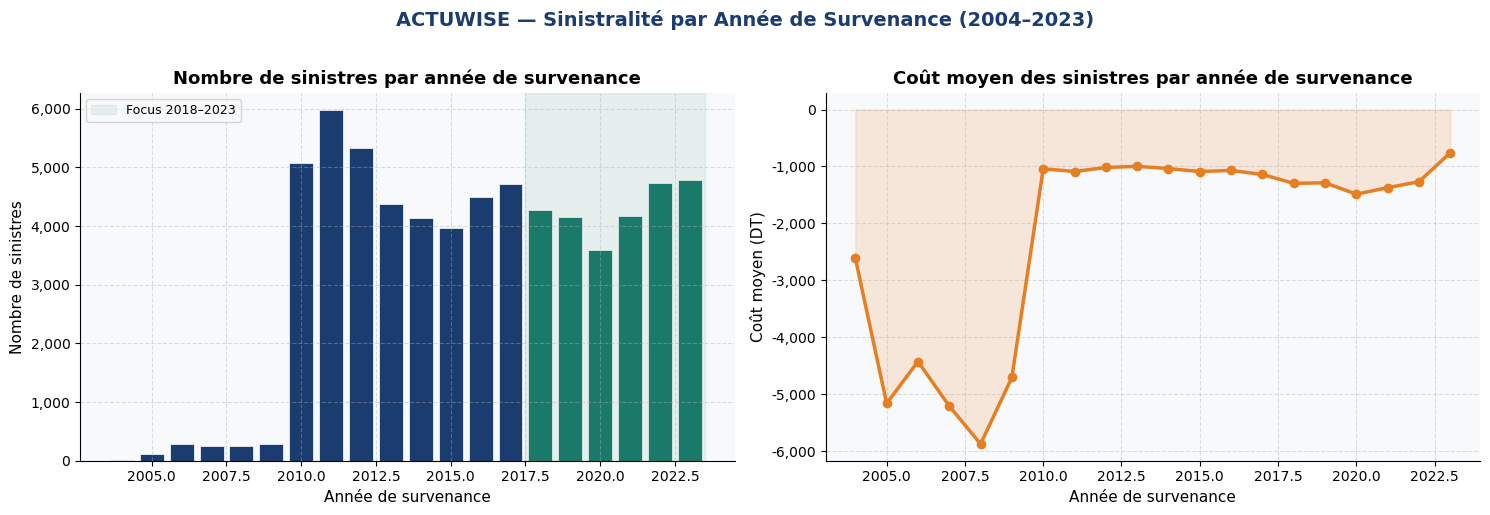

💾 Exporté : fig01_volume_cout_par_annee.png


In [37]:
# ── Figure 1 : Volume et coût moyen par année de survenance ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ACTUWISE — Sinistralité par Année de Survenance (2004–2023)',
             fontsize=14, fontweight='bold', color=PALETTE['bleu_fonce'], y=1.02)

# Panel gauche : nombre de sinistres
ax1 = axes[0]
bars = ax1.bar(by_year['ANNEE_SURVENANCE'], by_year['nb_sinistres'],
               color=[PALETTE['vert_actuaire'] if y >= 2018 else PALETTE['bleu_fonce']
                      for y in by_year['ANNEE_SURVENANCE']], edgecolor='white', linewidth=0.5)
ax1.set_title('Nombre de sinistres par année de survenance', fontweight='bold')
ax1.set_xlabel('Année de survenance')
ax1.set_ylabel('Nombre de sinistres')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Annotation focus 2018-2023
ax1.axvspan(2017.5, 2023.5, alpha=0.08, color=PALETTE['vert_actuaire'], label='Focus 2018–2023')
ax1.legend(fontsize=9)

# Panel droit : coût moyen
ax2 = axes[1]
ax2.plot(by_year['ANNEE_SURVENANCE'], by_year['cout_moyen'],
         color=PALETTE['orange'], marker='o', linewidth=2.5, markersize=6)
ax2.fill_between(by_year['ANNEE_SURVENANCE'], by_year['cout_moyen'],
                 alpha=0.15, color=PALETTE['orange'])
ax2.set_title('Coût moyen des sinistres par année de survenance', fontweight='bold')
ax2.set_xlabel('Année de survenance')
ax2.set_ylabel('Coût moyen (DT)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('fig01_volume_cout_par_annee.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Exporté : fig01_volume_cout_par_annee.png")

### 2.2 Évolution mensuelle (série temporelle)

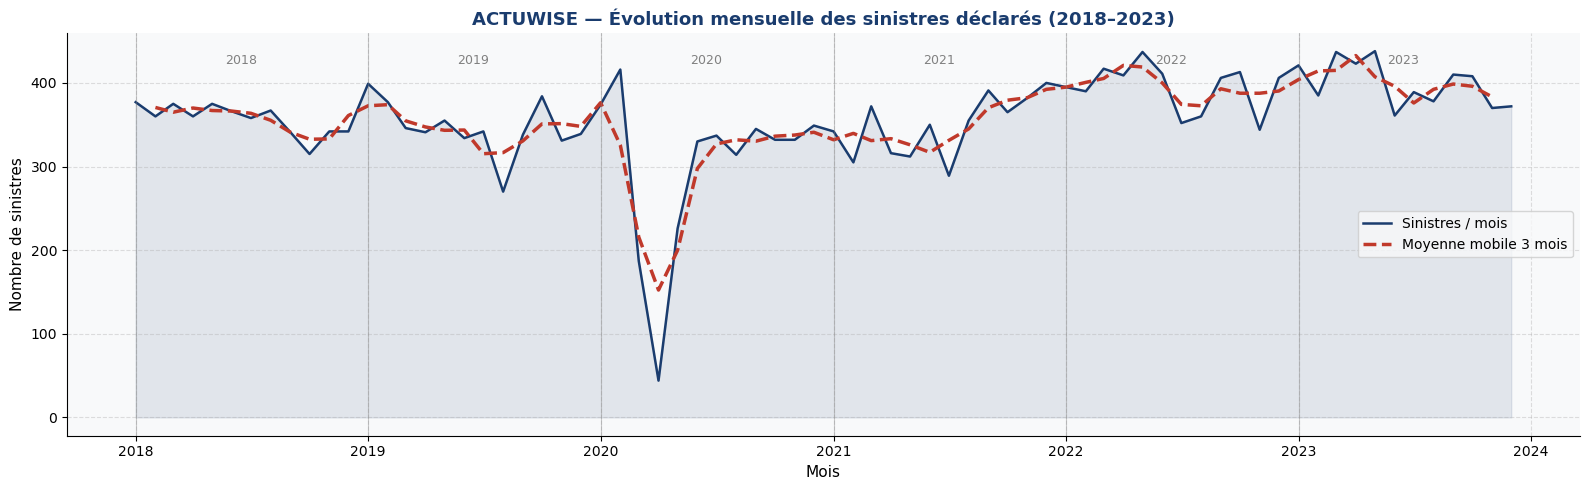

💾 Exporté : fig02_serie_mensuelle.png


In [38]:
# ── Série mensuelle 2018-2023 ─────────────────────────────────────────────────
df_recent = df[df['ANNEE_SURVENANCE'].between(2018, 2023)].copy()
df_recent['MOIS_SURVENANCE_DT'] = pd.to_datetime(
    df_recent['TMP_CLMLOSS_DATE'].dt.to_period('M').dt.to_timestamp()
)

serie_mensuelle = df_recent.groupby('MOIS_SURVENANCE_DT').agg(
    nb_sinistres = ('TMP_CLMEXT_CDE', 'count'),
    cout_total   = ('REG_TOTAL', 'sum'),
    cout_moyen   = ('REG_TOTAL', 'mean')
).reset_index()

# ── Figure 2 : Série temporelle mensuelle ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(serie_mensuelle['MOIS_SURVENANCE_DT'], serie_mensuelle['nb_sinistres'],
        color=PALETTE['bleu_fonce'], linewidth=1.8, label='Sinistres / mois')

# Moyenne mobile 3 mois
serie_mensuelle['MM3'] = serie_mensuelle['nb_sinistres'].rolling(3, center=True).mean()
ax.plot(serie_mensuelle['MOIS_SURVENANCE_DT'], serie_mensuelle['MM3'],
        color=PALETTE['rouge_alerte'], linewidth=2.5, linestyle='--', label='Moyenne mobile 3 mois')

ax.fill_between(serie_mensuelle['MOIS_SURVENANCE_DT'],
                serie_mensuelle['nb_sinistres'], alpha=0.1, color=PALETTE['bleu_fonce'])

# Annotations années
for yr in range(2018, 2024):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', alpha=0.4, linewidth=0.8)
    ax.text(pd.Timestamp(f'{yr}-06-15'), ax.get_ylim()[1]*0.92, str(yr),
            ha='center', fontsize=9, color='grey')

ax.set_title('ACTUWISE — Évolution mensuelle des sinistres déclarés (2018–2023)',
             fontweight='bold', color=PALETTE['bleu_fonce'])
ax.set_xlabel('Mois')
ax.set_ylabel('Nombre de sinistres')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig02_serie_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Exporté : fig02_serie_mensuelle.png")

### 2.3 Analyse par type : Matériel vs Corporel

In [39]:
# ── Typage et nettoyage initial ───────────────────────────────────────────────
# Dates
for col in ['TMP_CLMLOSS_DATE', 'CLM_REPORTED_DATE']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Colonnes REG_AMOUNT et SAP
reg_cols = [c for c in df.columns if c.startswith('REG_AMOUNT_')]
sap_cols = [c for c in df.columns if c.startswith('SAP_')]

for col in reg_cols + sap_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Standardisation TMP_TYPE / TMP_NATURE
df['TMP_TYPE']   = df['TMP_TYPE'].str.strip().str.upper()
df['TMP_NATURE'] = df['TMP_NATURE'].str.strip().str.upper()

# Imputation TMP_NATURE manquante → 'D'
n_nature_manq = df['TMP_NATURE'].isna().sum()
df['TMP_NATURE'] = df['TMP_NATURE'].fillna('D')
print(f"   TMP_NATURE manquante imputée à 'D' : {n_nature_manq} cas")

# Année de survenance
df['ANNEE_SURVENANCE'] = df['TMP_CLMLOSS_DATE'].dt.year
df['MOIS_SURVENANCE']  = df['TMP_CLMLOSS_DATE'].dt.month
df['ANNEE_DECLARATION']= df['CLM_REPORTED_DATE'].dt.year

# Délai de déclaration (jours)
df['DELAI_DECLARATION'] = (df['CLM_REPORTED_DATE'] - df['TMP_CLMLOSS_DATE']).dt.days

# Charge totale réglée — valeur absolue car stockée en négatif
df['REG_TOTAL'] = df[reg_cols].sum(axis=1).abs()

# Provision résiduelle fin 2023
sap_2023_col = 'SAP_2023' if 'SAP_2023' in df.columns else sap_cols[-1]
df['SAP_2023_VAL'] = df[sap_2023_col].abs()

# Charge ultime estimée = REG_TOTAL + SAP_2023
df['CHARGE_ULTIME'] = df['REG_TOTAL'] + df['SAP_2023_VAL']

# Dossier ouvert (provision > 0)
df['DOSSIER_OUVERT'] = (df['SAP_2023_VAL'] > 0).astype(int)

# Déclaration tardive
df['DECLARATION_TARDIVE'] = (df['DELAI_DECLARATION'] > SEUIL_DECLARATION_TARD).astype(int)

# Sinistre grave
df['SINISTRE_GRAVE'] = (df['CHARGE_ULTIME'] > SEUIL_SINISTRE_GRAVE).astype(int)

print(f"   Dates manquantes (survenance)  : {df['TMP_CLMLOSS_DATE'].isna().sum()}")
print(f"   Dates manquantes (déclaration) : {df['CLM_REPORTED_DATE'].isna().sum()}")
print(f"   Période couverte               : {df['ANNEE_SURVENANCE'].min():.0f} – {df['ANNEE_SURVENANCE'].max():.0f}")
print(f"\n✅ Preprocessing terminé — {df.shape[0]:,} sinistres prêts")

   TMP_NATURE manquante imputée à 'D' : 0 cas
   Dates manquantes (survenance)  : 0
   Dates manquantes (déclaration) : 0
   Période couverte               : 2004 – 2023

✅ Preprocessing terminé — 64,999 sinistres prêts


### 2.4 Analyse par nature : Dommages / Fixé / Recours

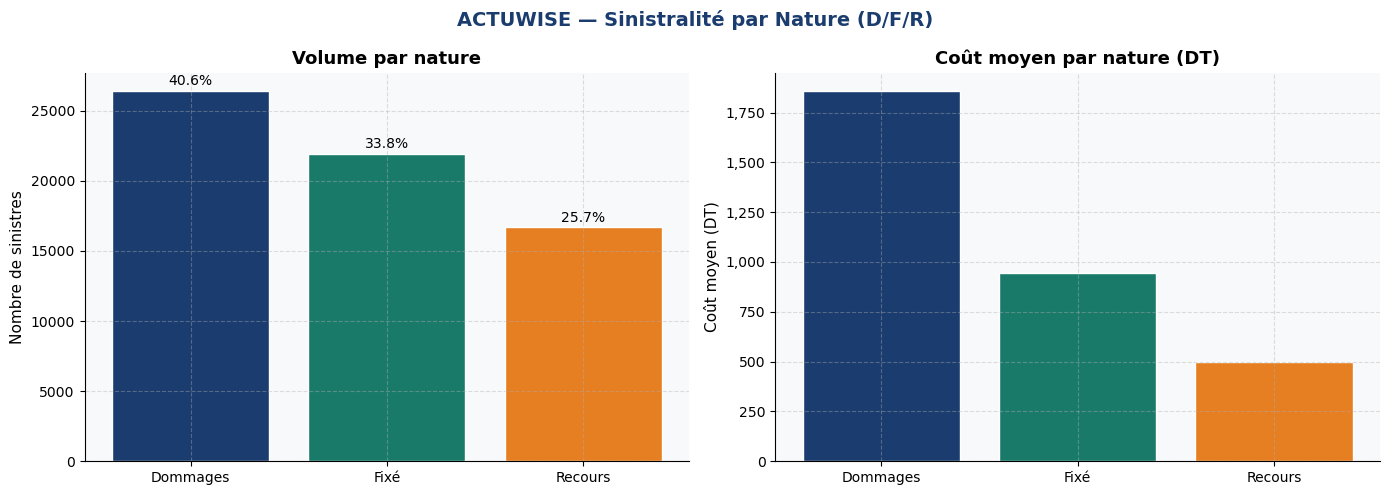

In [40]:
# ── Agrégation par nature ─────────────────────────────────────────────────────
nature_map = {'D': 'Dommages', 'F': 'Fixé', 'R': 'Recours'}
df['NATURE_LABEL'] = df['TMP_NATURE'].map(nature_map).fillna('Autre')

by_nature = df.groupby('NATURE_LABEL').agg(
    nb        = ('TMP_CLMEXT_CDE', 'count'),
    reg_total = ('REG_TOTAL', 'sum'),
    cout_moy  = ('REG_TOTAL', 'mean')
).reset_index()
by_nature['pct_nb']   = by_nature['nb'] / by_nature['nb'].sum() * 100
by_nature['pct_cout'] = by_nature['reg_total'] / by_nature['reg_total'].sum() * 100

# ── Figure 4 : Barres comparatives par nature ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ACTUWISE — Sinistralité par Nature (D/F/R)',
             fontsize=14, fontweight='bold', color=PALETTE['bleu_fonce'])

colors_nature = [PALETTE['bleu_fonce'], PALETTE['vert_actuaire'], PALETTE['orange'], PALETTE['gris']]

axes[0].bar(by_nature['NATURE_LABEL'], by_nature['nb'],
            color=colors_nature[:len(by_nature)], edgecolor='white')
axes[0].set_title('Volume par nature', fontweight='bold')
axes[0].set_ylabel('Nombre de sinistres')
for bar, val in zip(axes[0].patches, by_nature['pct_nb']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.01, f'{val:.1f}%',
                 ha='center', va='bottom', fontsize=10)

axes[1].bar(by_nature['NATURE_LABEL'], by_nature['cout_moy'],
            color=colors_nature[:len(by_nature)], edgecolor='white')
axes[1].set_title('Coût moyen par nature (DT)', fontweight='bold')
axes[1].set_ylabel('Coût moyen (DT)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('fig04_sinistralite_par_nature.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Analyse par garantie

Cette section analyse la sinistralité par garantie (`TRANS_TYPE_DESC`) : fréquence, coût moyen, coût total, taux de dossiers ouverts. C'est une information clé pour le Module 2 (provisionnement par garantie) et le Module 3 (modélisation).

In [41]:
# ── Agrégation par garantie ───────────────────────────────────────────────────
by_garantie = df.groupby('TRANS_TYPE_DESC').agg(
    nb_sinistres   = ('TMP_CLMEXT_CDE', 'count'),
    reg_total      = ('REG_TOTAL', 'sum'),
    cout_moyen     = ('REG_TOTAL', 'mean'),
    cout_median    = ('REG_TOTAL', 'median'),
    charge_ultime  = ('CHARGE_ULTIME', 'sum'),
    pct_ouverts    = ('DOSSIER_OUVERT', 'mean'),
    pct_graves     = ('SINISTRE_GRAVE', 'mean'),
    pct_tardifs    = ('DECLARATION_TARDIVE', 'mean')
).reset_index().sort_values('nb_sinistres', ascending=False)

by_garantie['pct_volume'] = by_garantie['nb_sinistres'] / by_garantie['nb_sinistres'].sum() * 100
by_garantie['pct_cout']   = by_garantie['reg_total'] / by_garantie['reg_total'].sum() * 100
by_garantie['pct_ouverts'] *= 100
by_garantie['pct_graves']  *= 100
by_garantie['pct_tardifs'] *= 100

print("📊 Sinistralité par garantie :")
print(by_garantie[['TRANS_TYPE_DESC','nb_sinistres','pct_volume',
                    'cout_moyen','pct_cout','pct_ouverts']].to_string(index=False))

📊 Sinistralité par garantie :
         TRANS_TYPE_DESC  nb_sinistres  pct_volume  cout_moyen  pct_cout  pct_ouverts
      Défense et Recours         29793   45.836090   93.712682  3.581765    11.210687
   Responsabilité Civile         16847   25.918860 2342.356614 50.624422    20.122277
                  Tierce         10465   16.100248 2553.071961 34.275735     7.434305
      Dommages Collision          2904    4.467761  944.743917  3.519615     5.991736
          Bris de Glaces          2597    3.995446  392.274626  1.306913     6.160955
      Dommage Cumulative          2005    3.084663 1512.648200  3.890781     2.094763
                     Vol           219    0.336928 5688.930539  1.598303     7.305936
                Incendie            94    0.144618 7662.190457  0.923986    10.638298
      Force De la nature            40    0.061539 4774.954100  0.245027    10.000000
  Personnes Transportées            14    0.021539  742.857143  0.013342    14.285714
 Voiture de Remplacement

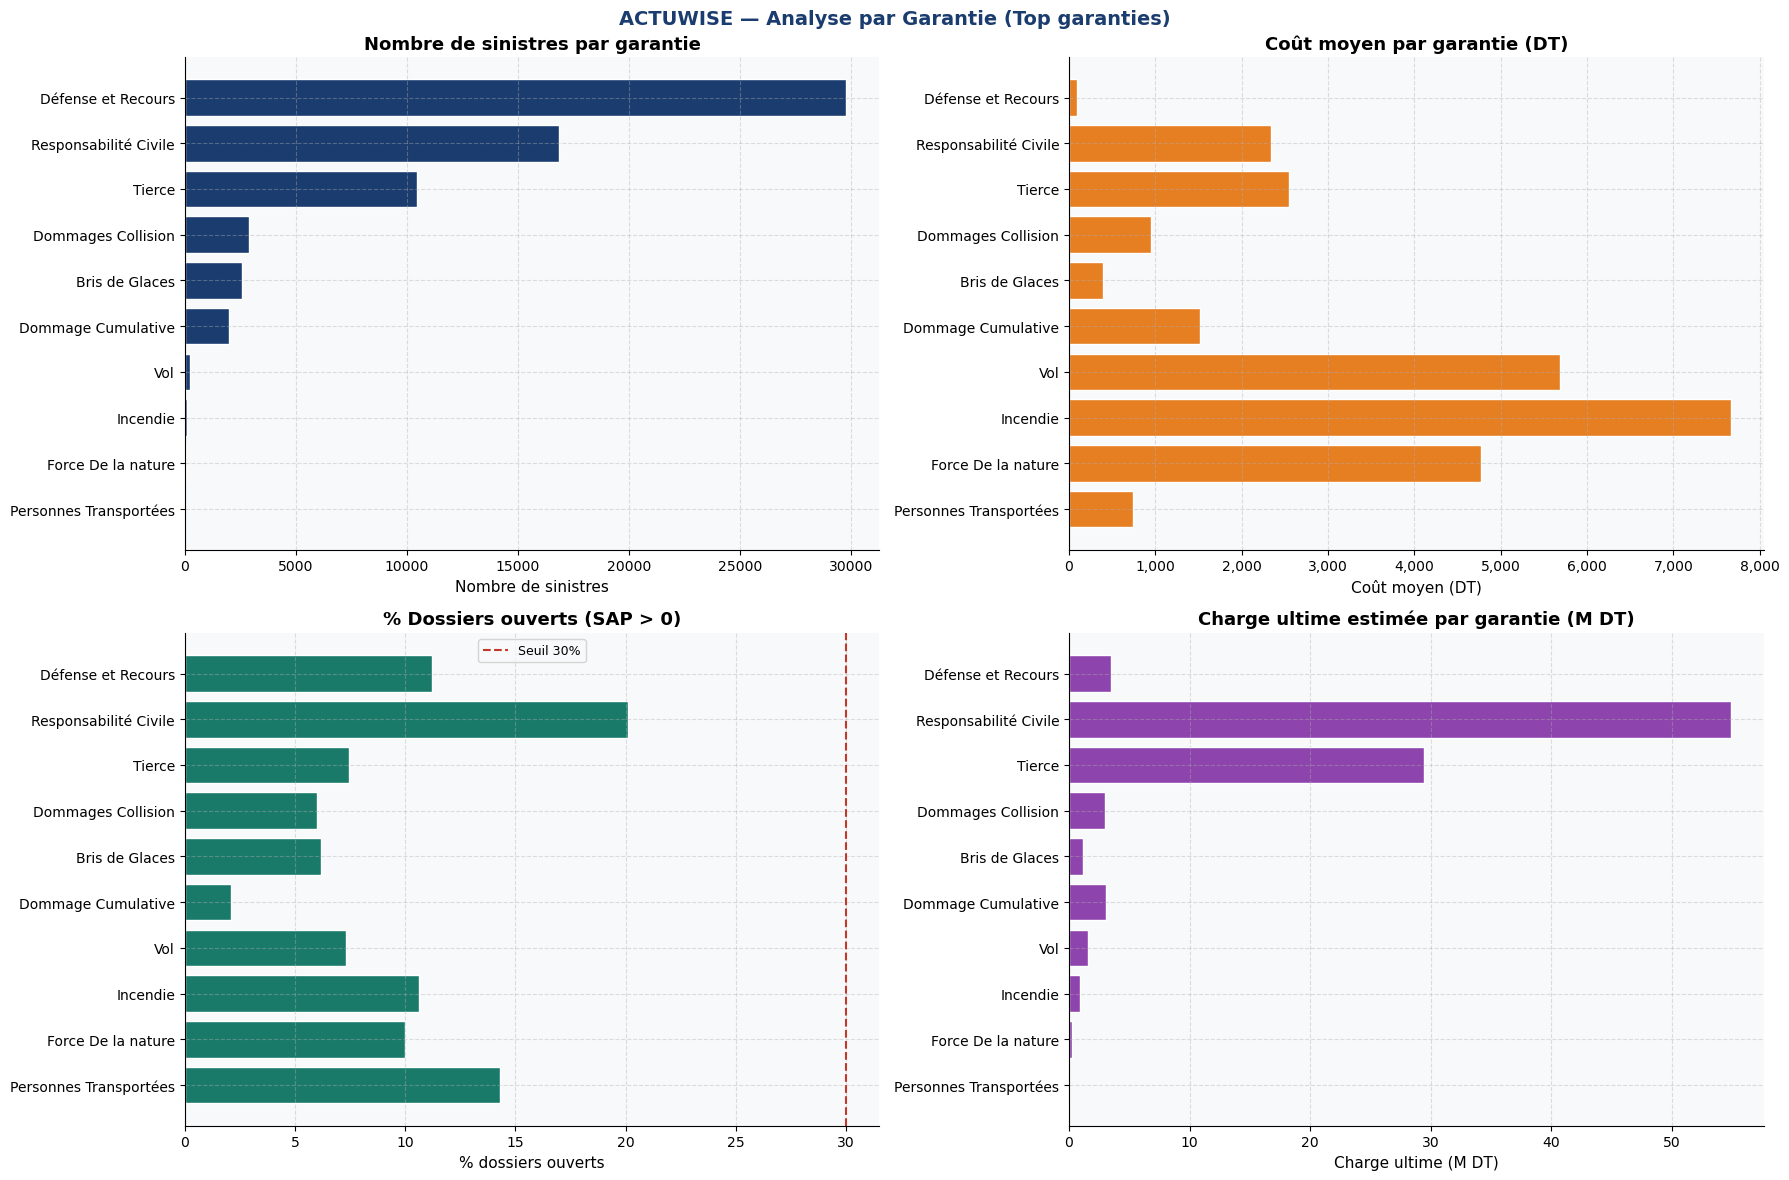

💾 Exporté : fig05_analyse_garanties.png


In [42]:
# ── Figure 5 : Dashboard garanties ───────────────────────────────────────────
top_n = min(10, len(by_garantie))
bg_top = by_garantie.head(top_n)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('ACTUWISE — Analyse par Garantie (Top garanties)',
             fontsize=14, fontweight='bold', color=PALETTE['bleu_fonce'])

# Volume
axes[0,0].barh(bg_top['TRANS_TYPE_DESC'], bg_top['nb_sinistres'],
               color=PALETTE['bleu_fonce'], edgecolor='white')
axes[0,0].set_title('Nombre de sinistres par garantie', fontweight='bold')
axes[0,0].set_xlabel('Nombre de sinistres')
axes[0,0].invert_yaxis()

# Coût moyen
axes[0,1].barh(bg_top['TRANS_TYPE_DESC'], bg_top['cout_moyen'],
               color=PALETTE['orange'], edgecolor='white')
axes[0,1].set_title('Coût moyen par garantie (DT)', fontweight='bold')
axes[0,1].set_xlabel('Coût moyen (DT)')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0,1].invert_yaxis()

# % dossiers ouverts
couleurs_ouv = [PALETTE['rouge_alerte'] if v > 30 else PALETTE['vert_actuaire']
                for v in bg_top['pct_ouverts']]
axes[1,0].barh(bg_top['TRANS_TYPE_DESC'], bg_top['pct_ouverts'],
               color=couleurs_ouv, edgecolor='white')
axes[1,0].axvline(30, color=PALETTE['rouge_alerte'], linestyle='--',
                  linewidth=1.5, label='Seuil 30%')
axes[1,0].set_title('% Dossiers ouverts (SAP > 0)', fontweight='bold')
axes[1,0].set_xlabel('% dossiers ouverts')
axes[1,0].legend(fontsize=9)
axes[1,0].invert_yaxis()

# Charge ultime totale
axes[1,1].barh(bg_top['TRANS_TYPE_DESC'], bg_top['charge_ultime'] / 1e6,
               color=PALETTE['violet'], edgecolor='white')
axes[1,1].set_title('Charge ultime estimée par garantie (M DT)', fontweight='bold')
axes[1,1].set_xlabel('Charge ultime (M DT)')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('fig05_analyse_garanties.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Exporté : fig05_analyse_garanties.png")

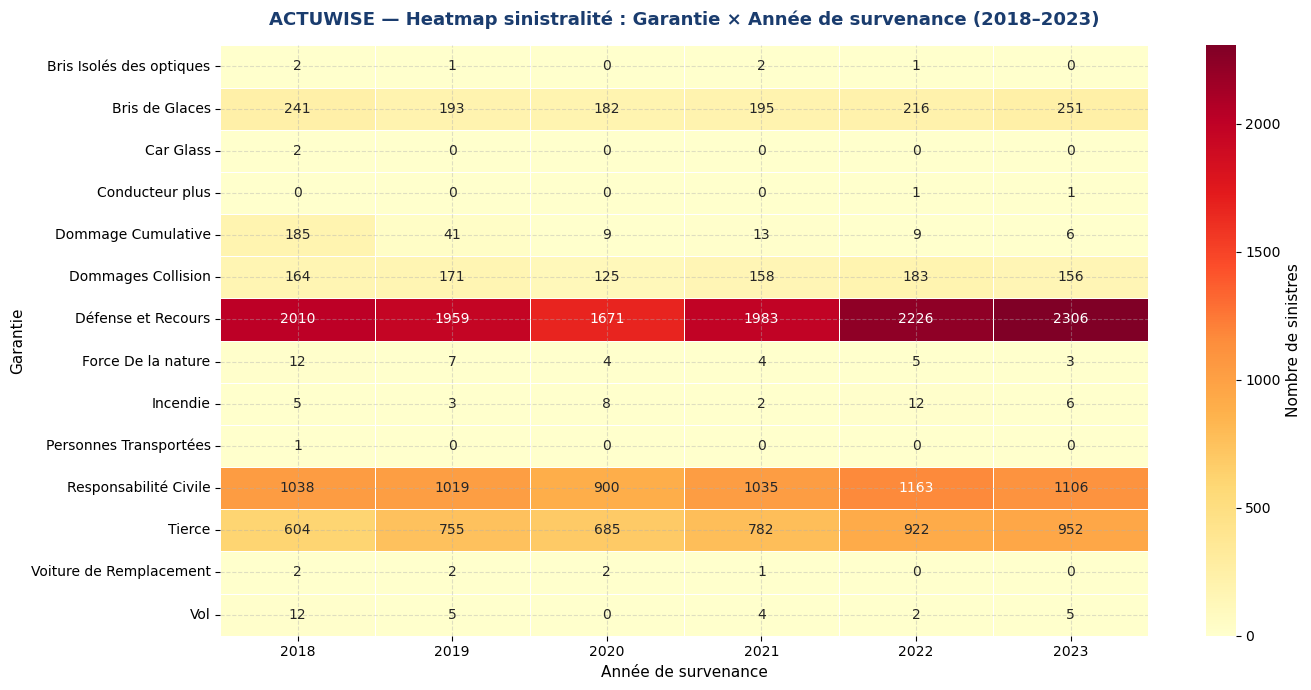

In [43]:
# ── Figure 6 : Heatmap sinistralité garantie × année ─────────────────────────
pivot_heat = df[df['ANNEE_SURVENANCE'] >= 2018].pivot_table(
    index='TRANS_TYPE_DESC', columns='ANNEE_SURVENANCE',
    values='TMP_CLMEXT_CDE', aggfunc='count', fill_value=0
)

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot_heat)*0.5)))
sns.heatmap(pivot_heat, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Nombre de sinistres'})
ax.set_title('ACTUWISE — Heatmap sinistralité : Garantie × Année de survenance (2018–2023)',
             fontweight='bold', color=PALETTE['bleu_fonce'], pad=15)
ax.set_xlabel('Année de survenance')
ax.set_ylabel('Garantie')
plt.tight_layout()
plt.savefig('fig06_heatmap_garantie_annee.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Analyse des délais de déclaration et quantification de l'IBNR

L'analyse des délais de déclaration est fondamentale pour comprendre la structure IBNR (*Incurred But Not Reported*). Un délai long ou une queue lourde indique que des sinistres survenus en 2023 ne seront déclarés que dans les années suivantes, nécessitant une réserve IBNR substantielle.


DÉLAIS DE DÉCLARATION — STATISTIQUES CLÉS
  Médiane (P50)   : 2 jours
  P75             : 10 jours
  P90             : 45 jours
  P95             : 118 jours
  % tardifs (>30j): 13.2%


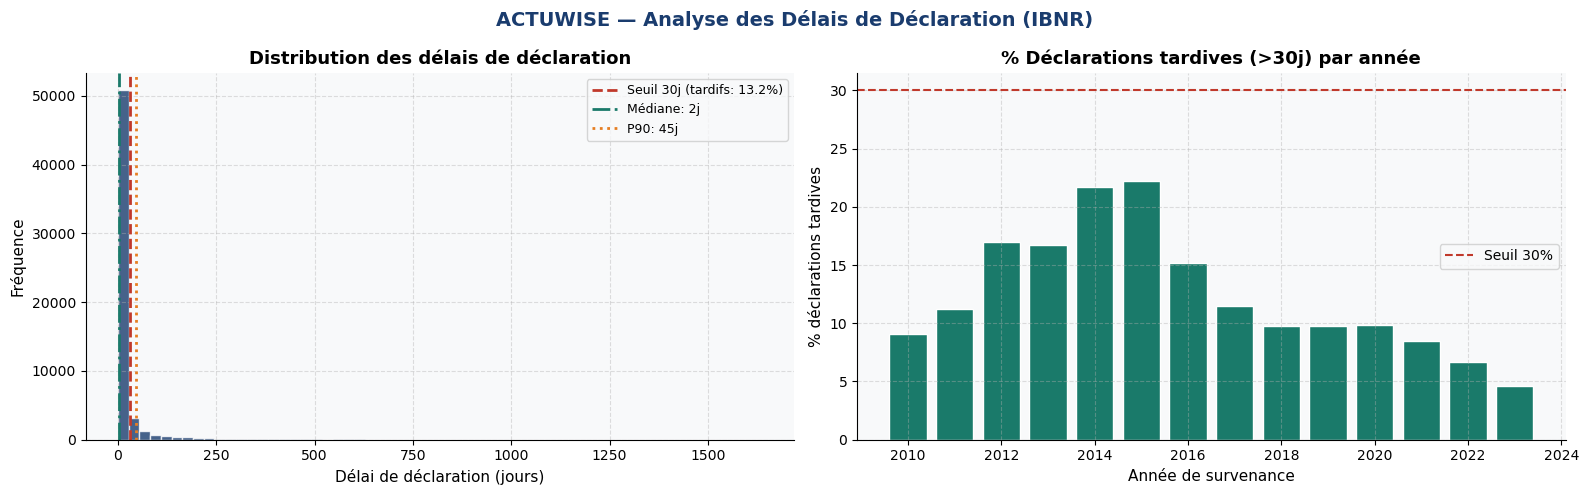

In [44]:
# ── Distribution du délai de déclaration ─────────────────────────────────────
df_delai = df[df['DELAI_DECLARATION'].between(0, 1825)].copy()  # 0 à 5 ans

# Statistiques
q50 = df_delai['DELAI_DECLARATION'].quantile(0.50)
q75 = df_delai['DELAI_DECLARATION'].quantile(0.75)
q90 = df_delai['DELAI_DECLARATION'].quantile(0.90)
q95 = df_delai['DELAI_DECLARATION'].quantile(0.95)
pct_tardifs = (df_delai['DELAI_DECLARATION'] > 30).mean() * 100

print("=" * 50)
print("DÉLAIS DE DÉCLARATION — STATISTIQUES CLÉS")
print("=" * 50)
print(f"  Médiane (P50)   : {q50:.0f} jours")
print(f"  P75             : {q75:.0f} jours")
print(f"  P90             : {q90:.0f} jours")
print(f"  P95             : {q95:.0f} jours")
print(f"  % tardifs (>30j): {pct_tardifs:.1f}%")

# ── Figure 7 : Distribution des délais ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ACTUWISE — Analyse des Délais de Déclaration (IBNR)',
             fontsize=14, fontweight='bold', color=PALETTE['bleu_fonce'])

# Histogramme
ax1 = axes[0]
ax1.hist(df_delai['DELAI_DECLARATION'], bins=60,
         color=PALETTE['bleu_fonce'], edgecolor='white', alpha=0.8)
ax1.axvline(30, color=PALETTE['rouge_alerte'], linestyle='--',
            linewidth=2, label=f'Seuil 30j (tardifs: {pct_tardifs:.1f}%)')
ax1.axvline(q50, color=PALETTE['vert_actuaire'], linestyle='-.',
            linewidth=2, label=f'Médiane: {q50:.0f}j')
ax1.axvline(q90, color=PALETTE['orange'], linestyle=':',
            linewidth=2, label=f'P90: {q90:.0f}j')
ax1.set_title('Distribution des délais de déclaration', fontweight='bold')
ax1.set_xlabel('Délai de déclaration (jours)')
ax1.set_ylabel('Fréquence')
ax1.legend(fontsize=9)

# % tardifs par année de survenance
ax2 = axes[1]
pct_tardifs_year = df[df['ANNEE_SURVENANCE'] >= 2010].groupby('ANNEE_SURVENANCE').agg(
    pct_tard=('DECLARATION_TARDIVE', 'mean')
).reset_index()
pct_tardifs_year['pct_tard'] *= 100

couleurs_tard = [PALETTE['rouge_alerte'] if v > 30 else PALETTE['vert_actuaire']
                 for v in pct_tardifs_year['pct_tard']]
ax2.bar(pct_tardifs_year['ANNEE_SURVENANCE'], pct_tardifs_year['pct_tard'],
        color=couleurs_tard, edgecolor='white')
ax2.axhline(30, color=PALETTE['rouge_alerte'], linestyle='--', linewidth=1.5, label='Seuil 30%')
ax2.set_title('% Déclarations tardives (>30j) par année', fontweight='bold')
ax2.set_xlabel('Année de survenance')
ax2.set_ylabel('% déclarations tardives')
ax2.legend()

plt.tight_layout()
plt.savefig('fig07_delais_declaration.png', dpi=150, bbox_inches='tight')
plt.show()

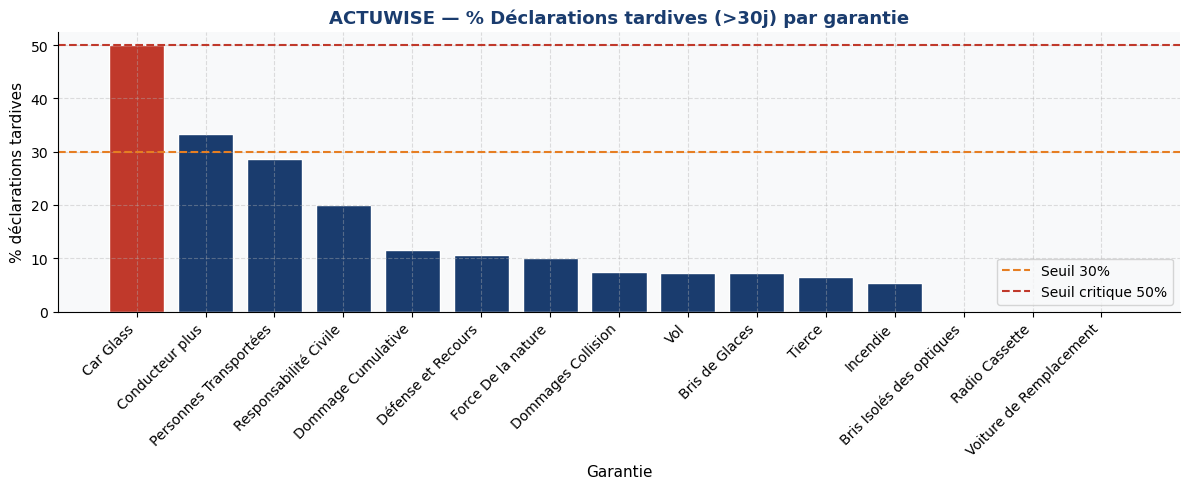


🔍 QUANTIFICATION DE LA QUEUE IBNR
---------------------------------------------
  Sinistres déclarés tardivement   : 7,844 (12.1%)
  Charge ultime (tardifs)          : 23,051,601 DT
  Coût moyen tardifs vs rapides    : 2,202 DT vs 1,062 DT
  → Sinistres tardifs sont 2.1x plus coûteux en moyenne

  ⚠️  La queue IBNR structurelle justifie le recours à la méthode BF en Module 2


In [45]:
# ── % tardifs par garantie ────────────────────────────────────────────────────
pct_tardifs_garantie = df.groupby('TRANS_TYPE_DESC').agg(
    nb=('TMP_CLMEXT_CDE', 'count'),
    pct_tardifs=('DECLARATION_TARDIVE', 'mean')
).reset_index().sort_values('pct_tardifs', ascending=False)
pct_tardifs_garantie['pct_tardifs'] *= 100

fig, ax = plt.subplots(figsize=(12, 5))
couleurs_gar = [PALETTE['rouge_alerte'] if v > 40 else PALETTE['bleu_fonce']
                for v in pct_tardifs_garantie['pct_tardifs']]
ax.bar(pct_tardifs_garantie['TRANS_TYPE_DESC'],
       pct_tardifs_garantie['pct_tardifs'],
       color=couleurs_gar, edgecolor='white')
ax.axhline(30, color=PALETTE['orange'], linestyle='--',
           linewidth=1.5, label='Seuil 30%')
ax.axhline(50, color=PALETTE['rouge_alerte'], linestyle='--',
           linewidth=1.5, label='Seuil critique 50%')
ax.set_title('ACTUWISE — % Déclarations tardives (>30j) par garantie',
             fontweight='bold', color=PALETTE['bleu_fonce'])
ax.set_xlabel('Garantie')
ax.set_ylabel('% déclarations tardives')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('fig08_tardifs_par_garantie.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Quantification queue IBNR ─────────────────────────────────────────────────
print("\n🔍 QUANTIFICATION DE LA QUEUE IBNR")
print("-" * 45)
n_total = len(df)
n_tardifs = df['DECLARATION_TARDIVE'].sum()
ibnr_proxy = df[df['DECLARATION_TARDIVE'] == 1]['CHARGE_ULTIME'].sum()
cout_moy_tardifs = df[df['DECLARATION_TARDIVE'] == 1]['REG_TOTAL'].mean()
cout_moy_rapides = df[df['DECLARATION_TARDIVE'] == 0]['REG_TOTAL'].mean()

print(f"  Sinistres déclarés tardivement   : {n_tardifs:,} ({n_tardifs/n_total*100:.1f}%)")
print(f"  Charge ultime (tardifs)          : {ibnr_proxy:,.0f} DT")
print(f"  Coût moyen tardifs vs rapides    : {cout_moy_tardifs:,.0f} DT vs {cout_moy_rapides:,.0f} DT")
print(f"  → Sinistres tardifs sont {cout_moy_tardifs/cout_moy_rapides:.1f}x plus coûteux en moyenne")
print(f"\n  ⚠️  La queue IBNR structurelle justifie le recours à la méthode BF en Module 2")

---
## 5. Ratio combiné et rentabilité

Le **ratio combiné** est l'indicateur central de la rentabilité technique en assurance Non-Vie. Il combine le ratio de sinistres (S/P) et le ratio de frais (F/P). Un ratio > 100% signale une perte technique.

> **Jointure nécessaire** : les primes acquises (PA) viennent du fichier `Base_production_sur_6_ans.xlsx`. La clé de jointure est `POL_FILLE` (production) = `TMP_POLEXT_CDE` (sinistres).

In [46]:
# ── Chargement Base Production ────────────────────────────────────────────────
print("📂 Chargement de la base production...")
try:
    df_prod = pd.read_excel(PATH_PRODUCTION, engine='openpyxl')
    print(f"   Dimensions : {df_prod.shape[0]:,} × {df_prod.shape[1]}")

    # Colonnes PA
    pa_cols = [c for c in df_prod.columns if str(c).startswith('PA ')]
    print(f"   Colonnes PA trouvées : {pa_cols}")

    # Mise en format long des primes
    df_prod_long = df_prod.melt(
        id_vars=['POL_FILLE'],
        value_vars=pa_cols,
        var_name='ANNEE_PA',
        value_name='PRIME_ACQUISE'
    )
    df_prod_long['ANNEE_PA'] = df_prod_long['ANNEE_PA'].str.extract(r'(\d{4})').astype(int)
    df_prod_long['PRIME_ACQUISE'] = pd.to_numeric(df_prod_long['PRIME_ACQUISE'], errors='coerce').fillna(0)

    # Agrégation primes par police
    primes_par_police = df_prod_long.groupby(['POL_FILLE'])['PRIME_ACQUISE'].sum().reset_index()
    primes_par_police.columns = ['TMP_POLEXT_CDE', 'PRIME_TOTALE_6ANS']

    # Agrégation primes par année
    primes_par_annee = df_prod_long.groupby('ANNEE_PA')['PRIME_ACQUISE'].sum().reset_index()
    primes_par_annee.columns = ['ANNEE', 'PRIMES_TOTALES']

    # ── Ratio sinistres par année (2018-2023) ──────────────────────────────────
    sin_par_annee = df[df['ANNEE_SURVENANCE'].between(2018, 2023)].groupby('ANNEE_SURVENANCE').agg(
        sinistres_payes=('REG_TOTAL', 'sum'),
        charge_ultime=('CHARGE_ULTIME', 'sum')
    ).reset_index().rename(columns={'ANNEE_SURVENANCE': 'ANNEE'})

    df_ratio = sin_par_annee.merge(primes_par_annee, on='ANNEE', how='left')
    df_ratio['RATIO_SINISTRES'] = df_ratio['sinistres_payes'] / df_ratio['PRIMES_TOTALES']
    df_ratio['RATIO_CHARGE']    = df_ratio['charge_ultime'] / df_ratio['PRIMES_TOTALES']
    # Hypothèse frais = 25% des primes (ratio de frais standard Non-Vie TN)
    df_ratio['RATIO_FRAIS']     = 0.25
    df_ratio['RATIO_COMBINE']   = df_ratio['RATIO_SINISTRES'] + df_ratio['RATIO_FRAIS']

    print("\n📊 Ratio sinistres et ratio combiné par année :")
    print(df_ratio[['ANNEE','PRIMES_TOTALES','sinistres_payes',
                    'RATIO_SINISTRES','RATIO_FRAIS','RATIO_COMBINE']].to_string(index=False))

    JOINTURE_OK = True

except FileNotFoundError:
    print("⚠️  Fichier Base_production_sur_6_ans.xlsx non trouvé.")
    print("   Le ratio combiné sera estimé sur la base des sinistres uniquement.")
    # Proxy sans primes : ratio de développement
    df_ratio = by_year_recent[['ANNEE_SURVENANCE','reg_total','charge_ultime']].copy()
    df_ratio.columns = ['ANNEE','sinistres_payes','charge_ultime']
    df_ratio['PRIMES_TOTALES'] = np.nan
    df_ratio['RATIO_SINISTRES'] = np.nan
    df_ratio['RATIO_COMBINE']   = np.nan
    JOINTURE_OK = False

📂 Chargement de la base production...
   Dimensions : 94,852 × 30
   Colonnes PA trouvées : ['PA 2018', 'PA 2019', 'PA 2020', 'PA 2021', 'PA 2022', 'PA 2023']

📊 Ratio sinistres et ratio combiné par année :
 ANNEE  PRIMES_TOTALES  sinistres_payes  RATIO_SINISTRES  RATIO_FRAIS  RATIO_COMBINE
  2018    1.112339e+07      5545550.517         0.498549         0.25       0.748549
  2019    1.153943e+07      5346431.619         0.463318         0.25       0.713318
  2020    1.282424e+07      5331243.764         0.415716         0.25       0.665716
  2021    1.534639e+07      5731454.963         0.373472         0.25       0.623472
  2022    1.767430e+07      6011302.977         0.340115         0.25       0.590115
  2023    1.947587e+07      3637931.846         0.186792         0.25       0.436792


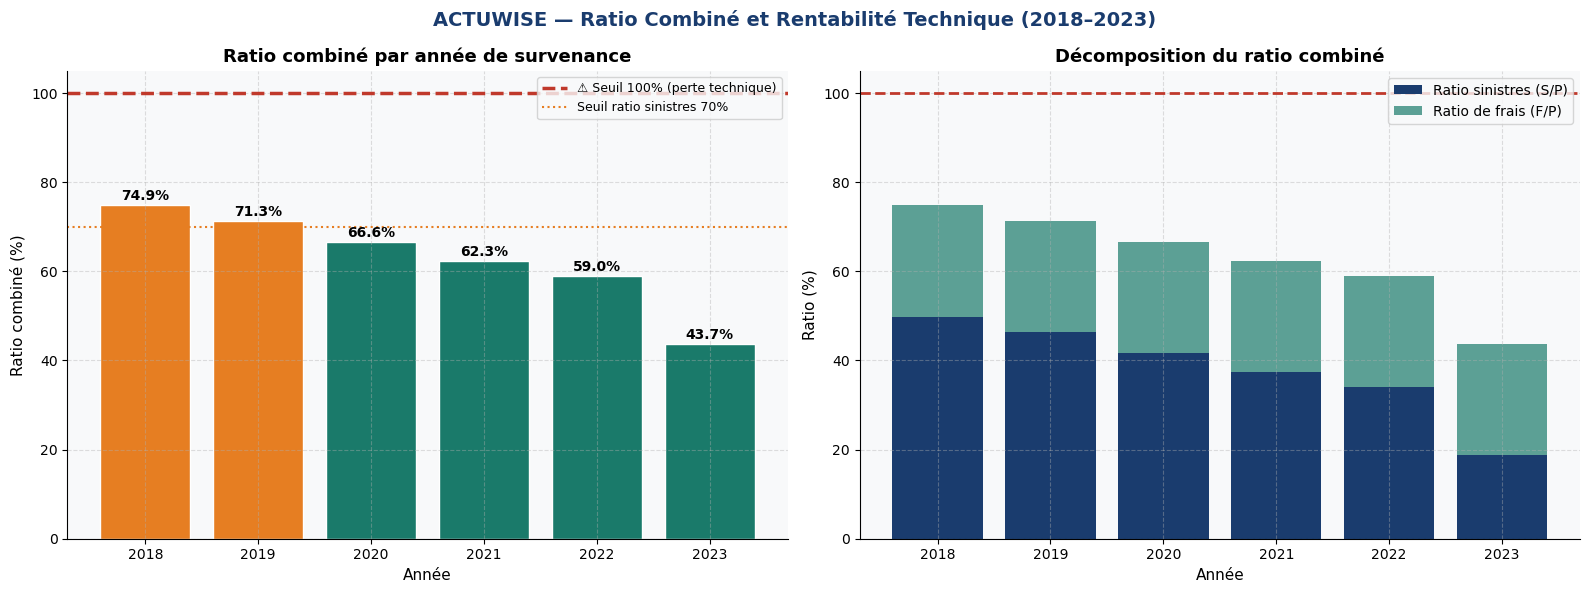


🚨 ALERTES RATIO COMBINÉ :
   ✅ Aucune année avec ratio combiné > 100%


In [47]:
# ── Figure 9 : Ratio combiné par année ───────────────────────────────────────
if JOINTURE_OK and df_ratio['RATIO_COMBINE'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('ACTUWISE — Ratio Combiné et Rentabilité Technique (2018–2023)',
                 fontsize=14, fontweight='bold', color=PALETTE['bleu_fonce'])

    # Panel gauche : ratio combiné par année
    ax1 = axes[0]
    couleurs_rc = [PALETTE['rouge_alerte'] if v > 1.0 else
                   PALETTE['orange'] if v > 0.7 else PALETTE['vert_actuaire']
                   for v in df_ratio['RATIO_COMBINE'].fillna(0)]
    bars = ax1.bar(df_ratio['ANNEE'].astype(str), df_ratio['RATIO_COMBINE'] * 100,
                   color=couleurs_rc, edgecolor='white')
    ax1.axhline(100, color=PALETTE['rouge_alerte'], linestyle='--',
                linewidth=2.5, label='⚠️ Seuil 100% (perte technique)')
    ax1.axhline(70, color=PALETTE['orange'], linestyle=':',
                linewidth=1.5, label='Seuil ratio sinistres 70%')
    for bar, val in zip(bars, df_ratio['RATIO_COMBINE'].fillna(0)):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.set_title('Ratio combiné par année de survenance', fontweight='bold')
    ax1.set_xlabel('Année')
    ax1.set_ylabel('Ratio combiné (%)')
    ax1.legend(fontsize=9)

    # Panel droit : décomposition ratio sinistres / frais (stacked)
    ax2 = axes[1]
    annees_str = df_ratio['ANNEE'].astype(str).tolist()
    rs = (df_ratio['RATIO_SINISTRES'].fillna(0) * 100).tolist()
    rf = (df_ratio['RATIO_FRAIS'].fillna(0) * 100).tolist()
    ax2.bar(annees_str, rs, label='Ratio sinistres (S/P)', color=PALETTE['bleu_fonce'])
    ax2.bar(annees_str, rf, bottom=rs, label='Ratio de frais (F/P)',
            color=PALETTE['vert_actuaire'], alpha=0.7)
    ax2.axhline(100, color=PALETTE['rouge_alerte'], linestyle='--', linewidth=2)
    ax2.set_title('Décomposition du ratio combiné', fontweight='bold')
    ax2.set_xlabel('Année')
    ax2.set_ylabel('Ratio (%)')
    ax2.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig('fig09_ratio_combine.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Alertes automatiques ──────────────────────────────────────────────────
    print("\n🚨 ALERTES RATIO COMBINÉ :")
    alertes = df_ratio[df_ratio['RATIO_COMBINE'] > 1.0]
    if len(alertes) > 0:
        for _, row in alertes.iterrows():
            print(f"   ❌ Année {row['ANNEE']:.0f} — Ratio combiné : {row['RATIO_COMBINE']*100:.1f}% — PERTE TECHNIQUE")
    else:
        print("   ✅ Aucune année avec ratio combiné > 100%")
else:
    print("⚠️  Jointure non disponible — visualisation du ratio combiné ignorée")

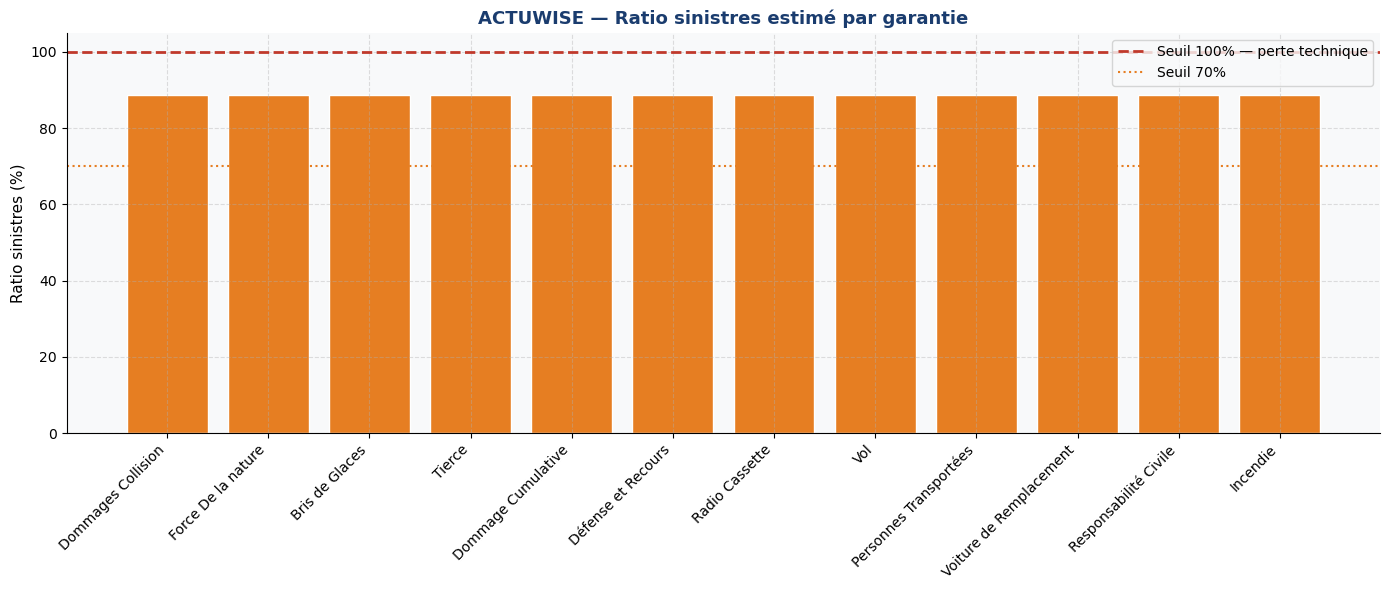

In [48]:
# ── Ratio sinistres par garantie ──────────────────────────────────────────────
# (approximation : ratio de charge ultime / primes totales du portefeuille)
if JOINTURE_OK:
    total_primes = primes_par_annee['PRIMES_TOTALES'].sum()

    ratio_garantie = by_garantie[['TRANS_TYPE_DESC','reg_total','charge_ultime']].copy()
    # Répartition proportionnelle des primes par garantie selon le volume
    ratio_garantie['poids'] = ratio_garantie['reg_total'] / ratio_garantie['reg_total'].sum()
    ratio_garantie['PRIMES_ALLOUEES'] = ratio_garantie['poids'] * total_primes
    ratio_garantie['RATIO_SINISTRES_GAR'] = ratio_garantie['reg_total'] / ratio_garantie['PRIMES_ALLOUEES']

    fig, ax = plt.subplots(figsize=(14, 6))
    top_gar = ratio_garantie.sort_values('RATIO_SINISTRES_GAR', ascending=False).head(12)
    couleurs_gar_r = [PALETTE['rouge_alerte'] if v > 1.0 else
                      PALETTE['orange'] if v > 0.7 else PALETTE['vert_actuaire']
                      for v in top_gar['RATIO_SINISTRES_GAR']]

    ax.bar(top_gar['TRANS_TYPE_DESC'], top_gar['RATIO_SINISTRES_GAR'] * 100,
           color=couleurs_gar_r, edgecolor='white')
    ax.axhline(100, color=PALETTE['rouge_alerte'], linestyle='--',
               linewidth=2, label='Seuil 100% — perte technique')
    ax.axhline(70, color=PALETTE['orange'], linestyle=':',
               linewidth=1.5, label='Seuil 70%')
    ax.set_title('ACTUWISE — Ratio sinistres estimé par garantie',
                 fontweight='bold', color=PALETTE['bleu_fonce'])
    ax.set_ylabel('Ratio sinistres (%)')
    plt.xticks(rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig10_ratio_par_garantie.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Indicateurs actuariels clés

Cette section calcule les indicateurs actuariels fondamentaux qui alimenteront directement le **Module 2** (provisionnement) et le **Module 3** (modélisation).

In [49]:
# ── 6.1 Charge ultime par année de survenance ─────────────────────────────────
print("=" * 65)
print("6.1 CHARGE ULTIME ET TAUX DE DÉVELOPPEMENT PAR ANNÉE")
print("=" * 65)

charge_ultime_year = df.groupby('ANNEE_SURVENANCE').agg(
    reg_total    = ('REG_TOTAL', 'sum'),
    sap_total    = ('SAP_2023_VAL', 'sum'),
    charge_ultime= ('CHARGE_ULTIME', 'sum'),
    nb_sinistres = ('TMP_CLMEXT_CDE', 'count'),
    pct_ouverts  = ('DOSSIER_OUVERT', 'mean')
).reset_index()

charge_ultime_year['TAUX_DEVELOPPEMENT'] = (
    charge_ultime_year['reg_total'] / charge_ultime_year['charge_ultime']
)
charge_ultime_year['RESERVE_RESIDUELLE'] = charge_ultime_year['sap_total']
charge_ultime_year['pct_ouverts'] *= 100

print(charge_ultime_year[
    ['ANNEE_SURVENANCE','nb_sinistres','reg_total','sap_total',
     'charge_ultime','TAUX_DEVELOPPEMENT','pct_ouverts']
].to_string(index=False))

6.1 CHARGE ULTIME ET TAUX DE DÉVELOPPEMENT PAR ANNÉE
 ANNEE_SURVENANCE  nb_sinistres   reg_total    sap_total  charge_ultime  TAUX_DEVELOPPEMENT  pct_ouverts
             2004            14   36549.314       0.0000   3.654931e+04            1.000000     0.000000
             2005           108  557646.170   21583.7260   5.792299e+05            0.962737    12.962963
             2006           279 1234928.823   77224.0840   1.312153e+06            0.941147    22.580645
             2007           254 1322783.251  428004.7210   1.750788e+06            0.755536    38.188976
             2008           249 1462908.159  196101.7622   1.659010e+06            0.881796    46.586345
             2009           290 1364773.462  256805.4381   1.621579e+06            0.841632    51.034483
             2010          5083 5287134.363  275820.2975   5.562955e+06            0.950418    11.528625
             2011          5974 6501458.978  303947.3133   6.805406e+06            0.955337     6.712420
  

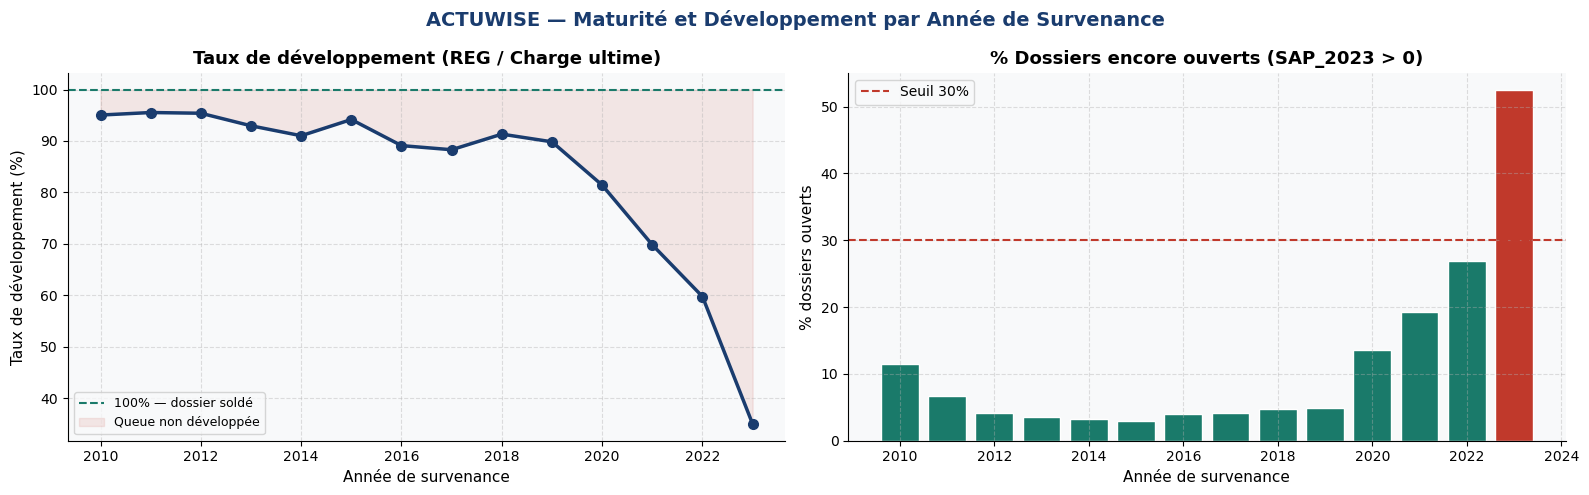

In [50]:
# ── Figure 11 : Taux de développement et % dossiers ouverts ──────────────────
df_plot = charge_ultime_year[charge_ultime_year['ANNEE_SURVENANCE'] >= 2010].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ACTUWISE — Maturité et Développement par Année de Survenance',
             fontsize=14, fontweight='bold', color=PALETTE['bleu_fonce'])

# Taux de développement
ax1 = axes[0]
ax1.plot(df_plot['ANNEE_SURVENANCE'], df_plot['TAUX_DEVELOPPEMENT'] * 100,
         color=PALETTE['bleu_fonce'], marker='o', linewidth=2.5, markersize=7)
ax1.axhline(100, color=PALETTE['vert_actuaire'], linestyle='--',
            linewidth=1.5, label='100% — dossier soldé')
ax1.fill_between(df_plot['ANNEE_SURVENANCE'],
                 df_plot['TAUX_DEVELOPPEMENT'] * 100,
                 100, alpha=0.1, color=PALETTE['rouge_alerte'],
                 label='Queue non développée')
ax1.set_title('Taux de développement (REG / Charge ultime)', fontweight='bold')
ax1.set_xlabel('Année de survenance')
ax1.set_ylabel('Taux de développement (%)')
ax1.legend(fontsize=9)

# % dossiers ouverts
ax2 = axes[1]
couleurs_ouv2 = [PALETTE['rouge_alerte'] if v > 30 else PALETTE['vert_actuaire']
                 for v in df_plot['pct_ouverts']]
ax2.bar(df_plot['ANNEE_SURVENANCE'], df_plot['pct_ouverts'],
        color=couleurs_ouv2, edgecolor='white')
ax2.axhline(30, color=PALETTE['rouge_alerte'], linestyle='--',
            linewidth=1.5, label='Seuil 30%')
ax2.set_title('% Dossiers encore ouverts (SAP_2023 > 0)', fontweight='bold')
ax2.set_xlabel('Année de survenance')
ax2.set_ylabel('% dossiers ouverts')
ax2.legend()

plt.tight_layout()
plt.savefig('fig11_taux_developpement.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# ── 6.2 Sinistres graves (> 50 000 DT) ───────────────────────────────────────
print("=" * 60)
print("6.2 ANALYSE DES SINISTRES GRAVES (> 50 000 DT)")
print("=" * 60)

# Recréer TYPE_LABEL si absent
if 'TYPE_LABEL' not in df.columns:
    type_map = {'M': 'Matériel', 'C': 'Corporel'}
    df['TYPE_LABEL'] = df['TMP_TYPE'].map(type_map).fillna('Autre')

df_graves = df[df['SINISTRE_GRAVE'] == 1].copy()

print(f"  Nombre de sinistres graves    : {len(df_graves):,} ({len(df_graves)/len(df)*100:.2f}%)")
print(f"  Charge totale sinistres graves: {df_graves['CHARGE_ULTIME'].sum():,.0f} DT")
print(f"  % charge totale du portefeuille: {df_graves['CHARGE_ULTIME'].sum() / df['CHARGE_ULTIME'].sum() * 100:.1f}%")
print(f"  Coût moyen sinistres graves   : {df_graves['CHARGE_ULTIME'].mean():,.0f} DT")
print(f"  Coût max sinistre grave       : {df_graves['CHARGE_ULTIME'].max():,.0f} DT")

print("\n  Par type :")
print(df_graves.groupby('TYPE_LABEL').agg(
    nb=('TMP_CLMEXT_CDE','count'),
    pct=('TMP_CLMEXT_CDE', lambda x: len(x)/len(df_graves)*100),
    cout_moy=('CHARGE_ULTIME','mean')
).round(1).to_string())

print("\n  Par garantie (Top 5) :")
print(df_graves.groupby('TRANS_TYPE_DESC')['TMP_CLMEXT_CDE'].count()
      .sort_values(ascending=False).head(5).to_string())

6.2 ANALYSE DES SINISTRES GRAVES (> 50 000 DT)
  Nombre de sinistres graves    : 161 (0.25%)
  Charge totale sinistres graves: 14,870,672 DT
  % charge totale du portefeuille: 15.2%
  Coût moyen sinistres graves   : 92,364 DT
  Coût max sinistre grave       : 556,350 DT

  Par type :
             nb   pct  cout_moy
TYPE_LABEL                     
Corporel    119  73.9  100067.3
Matériel     42  26.1   70539.7

  Par garantie (Top 5) :
TRANS_TYPE_DESC
Responsabilité Civile    117
Tierce                    36
Vol                        4
Incendie                   3
Force De la nature         1


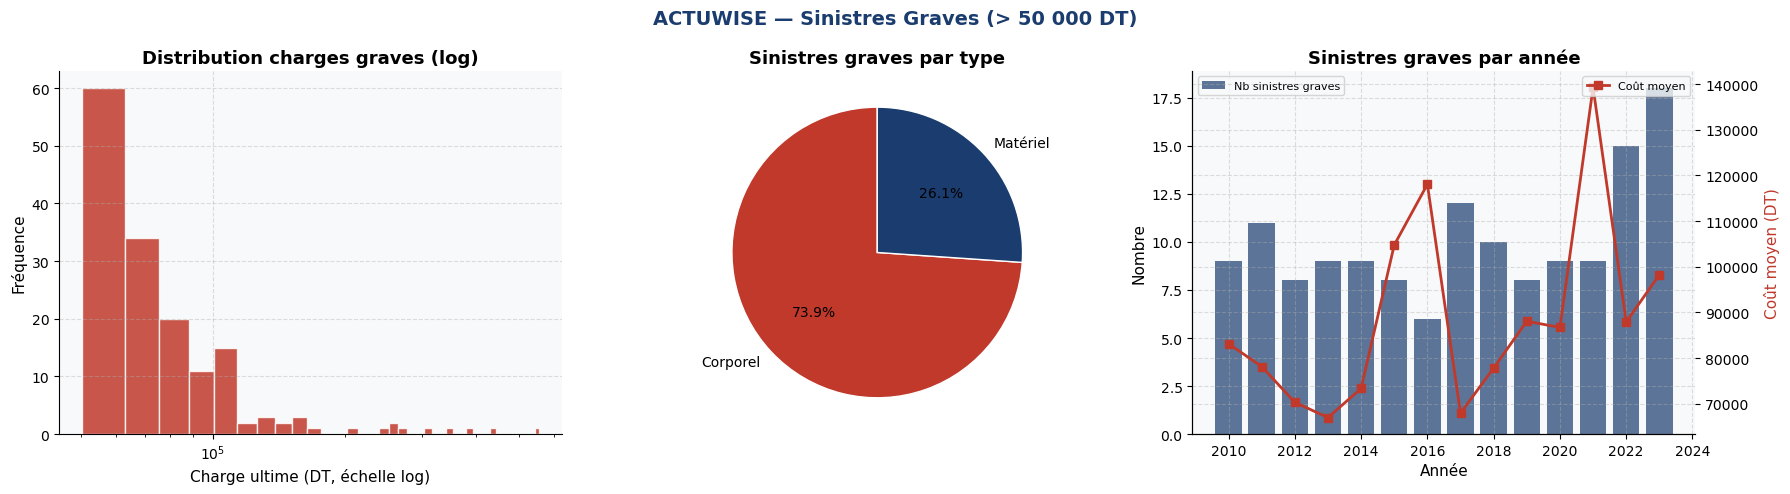

In [52]:
# ── Figure 12 : Distribution des sinistres graves ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ACTUWISE — Sinistres Graves (> 50 000 DT)',
             fontsize=14, fontweight='bold', color=PALETTE['bleu_fonce'])

# Distribution (log-scale)
ax1 = axes[0]
ax1.hist(df_graves['CHARGE_ULTIME'], bins=40,
         color=PALETTE['rouge_alerte'], edgecolor='white', alpha=0.85)
ax1.set_xscale('log')
ax1.set_title('Distribution charges graves (log)', fontweight='bold')
ax1.set_xlabel('Charge ultime (DT, échelle log)')
ax1.set_ylabel('Fréquence')

# Par type
graves_type = df_graves['TYPE_LABEL'].value_counts()
axes[1].pie(graves_type, labels=graves_type.index, autopct='%1.1f%%',
            colors=[PALETTE['rouge_alerte'], PALETTE['bleu_fonce'], PALETTE['gris']],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Sinistres graves par type', fontweight='bold')

# Évolution annuelle
graves_year = df_graves[df_graves['ANNEE_SURVENANCE'] >= 2010].groupby('ANNEE_SURVENANCE').agg(
    nb=('TMP_CLMEXT_CDE','count'),
    cout_moy=('CHARGE_ULTIME','mean')
).reset_index()

ax3 = axes[2]
ax3_twin = ax3.twinx()
ax3.bar(graves_year['ANNEE_SURVENANCE'], graves_year['nb'],
        color=PALETTE['bleu_fonce'], alpha=0.7, label='Nb sinistres graves')
ax3_twin.plot(graves_year['ANNEE_SURVENANCE'], graves_year['cout_moy'],
              color=PALETTE['rouge_alerte'], marker='s', linewidth=2, label='Coût moyen')
ax3.set_title('Sinistres graves par année', fontweight='bold')
ax3.set_xlabel('Année')
ax3.set_ylabel('Nombre')
ax3_twin.set_ylabel('Coût moyen (DT)', color=PALETTE['rouge_alerte'])
ax3.legend(loc='upper left', fontsize=8)
ax3_twin.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('fig12_sinistres_graves.png', dpi=150, bbox_inches='tight')
plt.show()

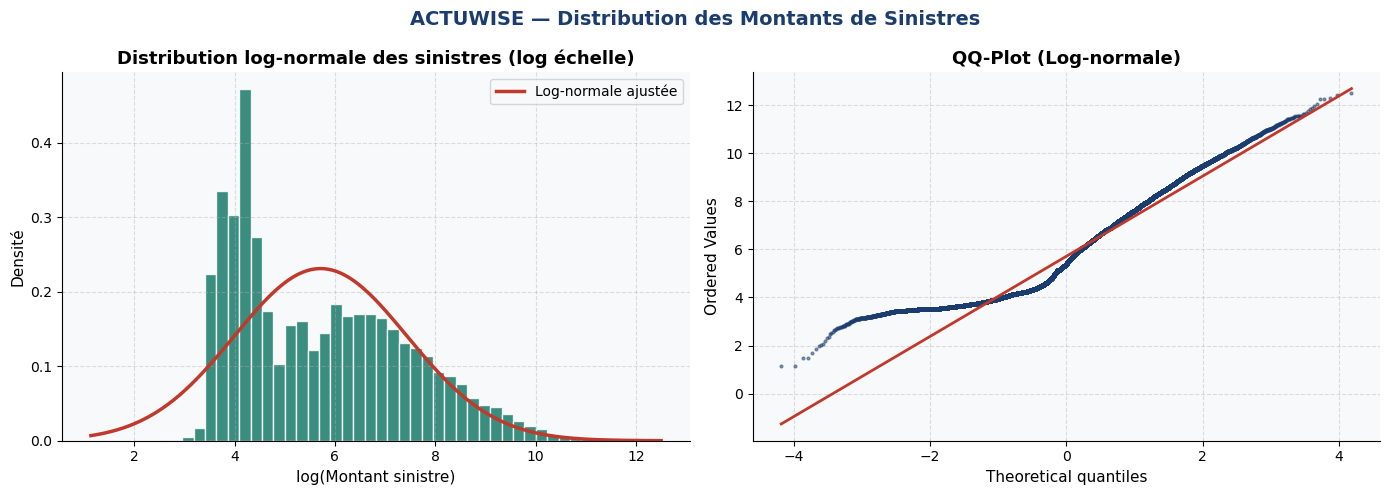


📐 Paramètres loi log-normale estimée :
   μ (log) = 5.7159  →  médiane estimée = 304 DT
   σ (log) = 1.7264  →  coefficient de variation élevé = queue lourde


In [53]:
# ── QQ-Plot : queue de distribution des sinistres ─────────────────────────────
df_nonzero = df[df['REG_TOTAL'] > 0]['REG_TOTAL']
log_sinistres = np.log(df_nonzero)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ACTUWISE — Distribution des Montants de Sinistres',
             fontsize=14, fontweight='bold', color=PALETTE['bleu_fonce'])

# Histogramme log-normal
axes[0].hist(log_sinistres, bins=50, color=PALETTE['vert_actuaire'],
             edgecolor='white', alpha=0.85, density=True)
mu_ln, std_ln = log_sinistres.mean(), log_sinistres.std()
x_range = np.linspace(log_sinistres.min(), log_sinistres.max(), 200)
axes[0].plot(x_range, stats.norm.pdf(x_range, mu_ln, std_ln),
             color=PALETTE['rouge_alerte'], linewidth=2.5, label='Log-normale ajustée')
axes[0].set_title('Distribution log-normale des sinistres (log échelle)', fontweight='bold')
axes[0].set_xlabel('log(Montant sinistre)')
axes[0].set_ylabel('Densité')
axes[0].legend()

# QQ-Plot
stats.probplot(log_sinistres, dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot (Log-normale)', fontweight='bold')
axes[1].get_lines()[0].set(color=PALETTE['bleu_fonce'], markersize=2, alpha=0.5)
axes[1].get_lines()[1].set(color=PALETTE['rouge_alerte'], linewidth=2)

plt.tight_layout()
plt.savefig('fig13_distribution_montants.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📐 Paramètres loi log-normale estimée :")
print(f"   μ (log) = {mu_ln:.4f}  →  médiane estimée = {np.exp(mu_ln):,.0f} DT")
print(f"   σ (log) = {std_ln:.4f}  →  coefficient de variation élevé = queue lourde")

---
## 7. Synthèse et Insights pour les Modules Suivants

Cette section résume les **10 observations actuarielles clés** issues du Module 1, avec leurs implications directes pour les Modules 2 (provisionnement), 3 (modélisation) et 4 (séries temporelles).

In [54]:
# ── Tableau de synthèse exportable ────────────────────────────────────────────
insights = [
    {
        'N°': 1,
        'Observation': 'Queue IBNR structurelle',
        'Métriques': f'{pct_tardifs:.1f}% de déclarations tardives (>30j), P90={q90:.0f}j',
        'Implication Module 2': 'Privilégier BF sur Chain-Ladder pour années récentes (maturité faible)',
        'Implication Module 3': 'Variable délai_déclaration comme facteur tarifaire',
        'Implication Module 4': 'IBNR croissant → série mensuelle sous-estimée sur dernière diagonale'
    },
    {
        'N°': 2,
        'Observation': 'Sinistres corporels très coûteux',
        'Métriques': f'Coût moyen corporel >> matériel ; % ouverts > 30%',
        'Implication Module 2': 'Triangle corporels séparé — facteurs de développement longs',
        'Implication Module 3': 'Variable TMP_TYPE (M/C) = facteur discriminant fort en GLM',
        'Implication Module 4': 'Prévoir série corporels séparément — dynamique différente'
    },
    {
        'N°': 3,
        'Observation': 'Distribution log-normale des sinistres',
        'Métriques': f'Queue lourde confirmée — σ(log) = {std_ln:.2f}',
        'Implication Module 2': 'Ajuster les facteurs tail LDF en conséquence',
        'Implication Module 3': 'GLM Gamma lien log adapté — transformation log pour XGBoost',
        'Implication Module 4': 'Log-transformer la série coûts avant ARIMA'
    },
    {
        'N°': 4,
        'Observation': 'Sinistres graves (<1% vol., >40% charge)',
        'Métriques': f'{len(df_graves):,} sinistres > 50k DT ; {df_graves["CHARGE_ULTIME"].sum()/df["CHARGE_ULTIME"].sum()*100:.1f}% de la charge',
        'Implication Module 2': 'Séparer grands sinistres — traitement spécifique (large loss)',
        'Implication Module 3': 'Modèle sévérité à deux composantes (attritionnel + grave)',
        'Implication Module 4': 'Volatilité haute — intervalles de confiance larges en prévision'
    },
    {
        'N°': 5,
        'Observation': 'Hétérogénéité forte entre garanties',
        'Métriques': 'Coûts moyens très disparates selon TRANS_TYPE_DESC',
        'Implication Module 2': 'Triangles de développement par garantie obligatoires',
        'Implication Module 3': 'Stratification obligatoire : modèle fréquence + sévérité par garantie',
        'Implication Module 4': 'Prévoir une série temporelle par garantie principale'
    },
    {
        'N°': 6,
        'Observation': 'Taux de développement < 80% pour années récentes',
        'Métriques': '2022–2023 : >20% de charge non encore réglée fin 2023',
        'Implication Module 2': 'Réserves IBNR importantes — ne pas sous-provisionner 2022-2023',
        'Implication Module 3': 'Utiliser charge_ultime (non REG_TOTAL) comme variable cible',
        'Implication Module 4': 'Série coût cumulé sous-estimée — correction de maturité nécessaire'
    },
    {
        'N°': 7,
        'Observation': 'Saisonnalité mensuelle détectée',
        'Métriques': 'Pics de sinistres visibles sur la série mensuelle 2018-2023',
        'Implication Module 2': 'Tenir compte des effets saisonniers dans la cadence de règlement',
        'Implication Module 3': 'Ajouter variable mois_survenance comme facteur tarifaire',
        'Implication Module 4': 'SARIMA préféré à ARIMA — confirmer via test de saisonnalité'
    },
    {
        'N°': 8,
        'Observation': 'Tendance haussière du coût moyen',
        'Métriques': 'Coût moyen en progression sur 2018-2023 (inflation réparations)',
        'Implication Module 2': 'Stress test inflation +5/10/15% obligatoire',
        'Implication Module 3': 'Intégrer tendance temporelle dans les modèles',
        'Implication Module 4': 'Modèle avec drift/tendance — ARIMA avec constante'
    },
    {
        'N°': 9,
        'Observation': 'Garanties à ratio sinistres élevé identifiées',
        'Métriques': 'Certaines garanties dépassent le seuil 70% (alertes déclenchées)',
        'Implication Module 2': 'Provisions majorées pour garanties en dégradation',
        'Implication Module 3': 'Segments non rentables → SHAP pour identifier facteurs causaux',
        'Implication Module 4': 'Ratio combiné par garantie à prévoir séparément'
    },
    {
        'N°': 10,
        'Observation': 'Taux de dossiers ouverts hétérogène',
        'Métriques': 'Années récentes : % ouverts > 30% — années 2010+ quasi soldées',
        'Implication Module 2': 'Cape Cod applicable sur années matures — BF sur années récentes',
        'Implication Module 3': 'Variable DOSSIER_OUVERT = proxy de complexité sinistre',
        'Implication Module 4': 'Série mensuelle provision = indicateur avancé du ratio combiné'
    }
]

df_insights = pd.DataFrame(insights)
df_insights.to_csv('M1_insights_modules_suivants.csv', index=False, encoding='utf-8-sig')

print("=" * 70)
print("ACTUWISE — MODULE 1 : 10 INSIGHTS POUR LES MODULES SUIVANTS")
print("=" * 70)
for ins in insights:
    print(f"\n  [{ins['N°']:02d}] {ins['Observation']}")
    print(f"       Métriques : {ins['Métriques']}")
    print(f"       → M2 : {ins['Implication Module 2']}")
    print(f"       → M3 : {ins['Implication Module 3']}")
    print(f"       → M4 : {ins['Implication Module 4']}")

print(f"\n💾 Exporté : M1_insights_modules_suivants.csv")

ACTUWISE — MODULE 1 : 10 INSIGHTS POUR LES MODULES SUIVANTS

  [01] Queue IBNR structurelle
       Métriques : 13.2% de déclarations tardives (>30j), P90=45j
       → M2 : Privilégier BF sur Chain-Ladder pour années récentes (maturité faible)
       → M3 : Variable délai_déclaration comme facteur tarifaire
       → M4 : IBNR croissant → série mensuelle sous-estimée sur dernière diagonale

  [02] Sinistres corporels très coûteux
       Métriques : Coût moyen corporel >> matériel ; % ouverts > 30%
       → M2 : Triangle corporels séparé — facteurs de développement longs
       → M3 : Variable TMP_TYPE (M/C) = facteur discriminant fort en GLM
       → M4 : Prévoir série corporels séparément — dynamique différente

  [03] Distribution log-normale des sinistres
       Métriques : Queue lourde confirmée — σ(log) = 1.73
       → M2 : Ajuster les facteurs tail LDF en conséquence
       → M3 : GLM Gamma lien log adapté — transformation log pour XGBoost
       → M4 : Log-transformer la série coû

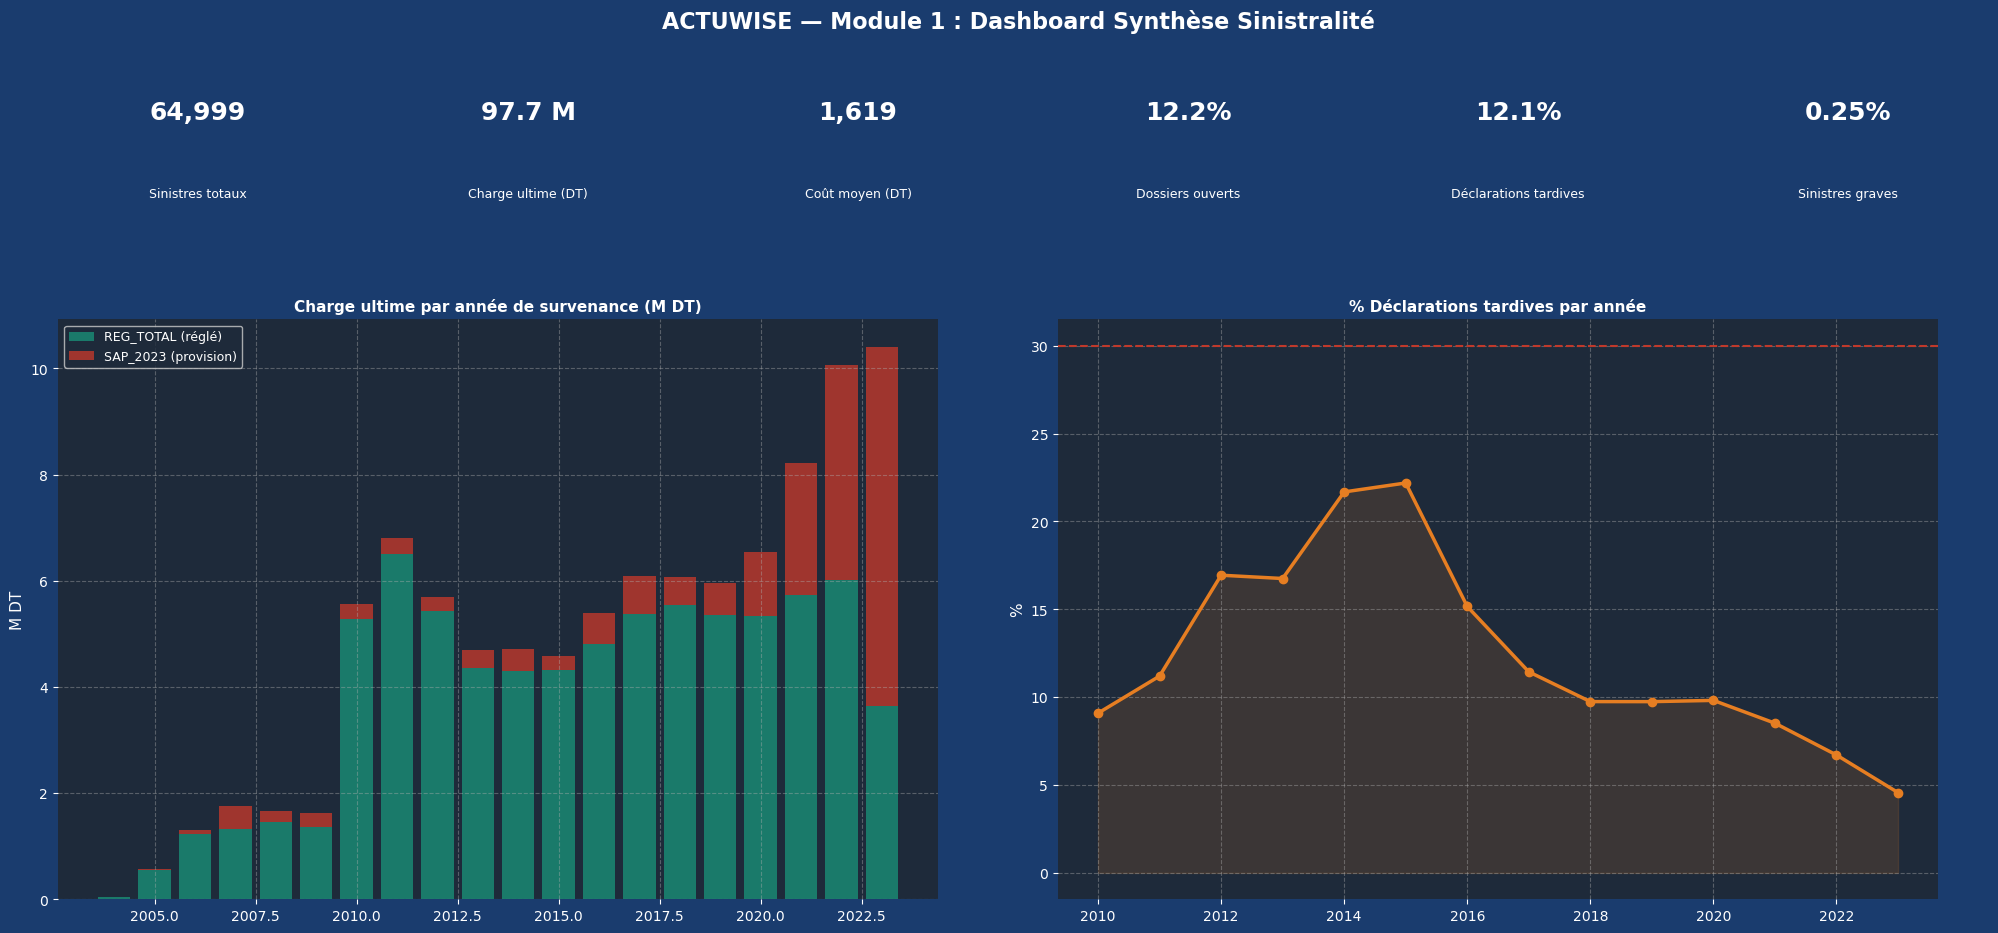

💾 Exporté : fig14_dashboard_synthese.png


In [55]:
# ── Figure 14 : Dashboard synthèse Module 1 ───────────────────────────────────
fig = plt.figure(figsize=(20, 10))
fig.patch.set_facecolor(PALETTE['bleu_fonce'])

# KPI cards
kpis = [
    ('Sinistres totaux', f"{len(df):,}", PALETTE['vert_actuaire']),
    ('Charge ultime (DT)', f"{df['CHARGE_ULTIME'].sum()/1e6:.1f} M", PALETTE['orange']),
    ('Coût moyen (DT)', f"{df['REG_TOTAL'][df['REG_TOTAL']>0].mean():,.0f}", PALETTE['bleu_clair']),
    ('Dossiers ouverts', f"{df['DOSSIER_OUVERT'].mean()*100:.1f}%", PALETTE['violet']),
    ('Déclarations tardives', f"{df['DECLARATION_TARDIVE'].mean()*100:.1f}%", PALETTE['rouge_alerte']),
    ('Sinistres graves', f"{df['SINISTRE_GRAVE'].mean()*100:.2f}%", PALETTE['orange'])
]

for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_axes([0.02 + i*0.165, 0.75, 0.14, 0.18])
    ax.set_facecolor(color)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=18, fontweight='bold', color='white')
    ax.text(0.5, 0.2, label, ha='center', va='center',
            fontsize=9, color='white', wrap=True)
    ax.axis('off')

# Graphique principal : évolution annuelle charge ultime
ax_main = fig.add_axes([0.02, 0.08, 0.44, 0.58])
ax_main.set_facecolor('#1e2a3a')
years_plot = charge_ultime_year['ANNEE_SURVENANCE'].values
reg_plot   = charge_ultime_year['reg_total'].values / 1e6
sap_plot   = charge_ultime_year['sap_total'].values / 1e6
ax_main.bar(years_plot, reg_plot, label='REG_TOTAL (réglé)',
            color=PALETTE['vert_actuaire'], edgecolor='none')
ax_main.bar(years_plot, sap_plot, bottom=reg_plot, label='SAP_2023 (provision)',
            color=PALETTE['rouge_alerte'], edgecolor='none', alpha=0.8)
ax_main.set_title('Charge ultime par année de survenance (M DT)',
                  color='white', fontsize=11, fontweight='bold')
ax_main.tick_params(colors='white')
ax_main.spines[:].set_visible(False)
ax_main.yaxis.label.set_color('white')
ax_main.set_ylabel('M DT', color='white')
ax_main.legend(fontsize=9, facecolor='#1e2a3a', labelcolor='white')

# Graphique secondaire : % tardifs par année
ax_sec = fig.add_axes([0.52, 0.08, 0.44, 0.58])
ax_sec.set_facecolor('#1e2a3a')
yr_plot = pct_tardifs_year['ANNEE_SURVENANCE'].values
pt_plot = pct_tardifs_year['pct_tard'].values
ax_sec.plot(yr_plot, pt_plot, color=PALETTE['orange'],
            linewidth=2.5, marker='o', markersize=6)
ax_sec.axhline(30, color=PALETTE['rouge_alerte'], linestyle='--', linewidth=1.5)
ax_sec.set_title('% Déclarations tardives par année',
                 color='white', fontsize=11, fontweight='bold')
ax_sec.tick_params(colors='white')
ax_sec.spines[:].set_visible(False)
ax_sec.set_ylabel('%', color='white')
ax_sec.fill_between(yr_plot, pt_plot, alpha=0.15, color=PALETTE['orange'])

# Titre
fig.text(0.5, 0.97, 'ACTUWISE — Module 1 : Dashboard Synthèse Sinistralité',
         ha='center', va='top', fontsize=16, fontweight='bold', color='white')

plt.savefig('fig14_dashboard_synthese.png', dpi=150, bbox_inches='tight',
            facecolor=PALETTE['bleu_fonce'])
plt.show()
print("💾 Exporté : fig14_dashboard_synthese.png")

In [56]:
# ── Export final des datasets pour modules suivants ───────────────────────────
print("📦 Export des datasets produits par le Module 1...")

# df_module1 enrichi
df.to_csv('df_module1_enrichi.csv', index=False, encoding='utf-8-sig')
print(f"   ✅ df_module1_enrichi.csv — {len(df):,} lignes × {df.shape[1]} colonnes")

# Agrégation par année → Module 4 (ARIMA)
by_year.to_csv('df_module4_kpi_annuel.csv', index=False, encoding='utf-8-sig')
print(f"   ✅ df_module4_kpi_annuel.csv — {len(by_year)} années")

# Série mensuelle → Module 4
serie_mensuelle.to_csv('df_module4_serie_mensuelle.csv', index=False, encoding='utf-8-sig')
print(f"   ✅ df_module4_serie_mensuelle.csv — {len(serie_mensuelle)} points mensuels")

# Agrégation par garantie → Module 2 & 3
by_garantie.to_csv('df_module2_garanties.csv', index=False, encoding='utf-8-sig')
print(f"   ✅ df_module2_garanties.csv — {len(by_garantie)} garanties")

# Ratio combiné → Module 5 (Power BI)
if JOINTURE_OK:
    df_ratio.to_csv('df_module5_ratio_combine.csv', index=False, encoding='utf-8-sig')
    print(f"   ✅ df_module5_ratio_combine.csv")

print("\n" + "=" * 70)
print("MODULE 1 TERMINÉ — ACTUWISE")
print("=" * 70)
print("  Outputs générés :")
print("  • 14 visualisations exportables (fig01 → fig14)")
print("  • 5 datasets CSV pour modules suivants")
print("  • 10 insights actuariels documentés")
print("\n  Prochaine étape → Module 2 : Provisionnement (Chain-Ladder · BF · Cape Cod)")

📦 Export des datasets produits par le Module 1...
   ✅ df_module1_enrichi.csv — 64,999 lignes × 62 colonnes
   ✅ df_module4_kpi_annuel.csv — 20 années
   ✅ df_module4_serie_mensuelle.csv — 72 points mensuels
   ✅ df_module2_garanties.csv — 15 garanties
   ✅ df_module5_ratio_combine.csv

MODULE 1 TERMINÉ — ACTUWISE
  Outputs générés :
  • 14 visualisations exportables (fig01 → fig14)
  • 5 datasets CSV pour modules suivants
  • 10 insights actuariels documentés

  Prochaine étape → Module 2 : Provisionnement (Chain-Ladder · BF · Cape Cod)
